In [2]:
#####################################
# Goal of this code is to understand lag regression of Q1 
# to show the evolution of shallow, deep, stratiform in the tropics
# This is a more general characteristic of convection, not KW-specific
# The goal is to explain why EOF structures change
# 2024.7.26
###############################################

In [3]:
import os
import sys
sys.path.append('/glade/work/muting/function/')
import KW_diagnostics as KW
import mjo_mean_state_diagnostics as MJO
import create_my_colormap as mycolor
RWB = mycolor.red_white_blue()
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap 

In [22]:
dir_out            = '/glade/work/muting/KW/'
CASENAME_LIST2     = list(['SST_AQP3_Qobs_27_-4K',\
                          'SST_AQP3_Qobs_27',\
                          'SST_AQP3_Qobs_27_4K'])
CASENAME_SHORT_LIST = list(['-4K','CTL','4K'])
figdir              = dir_out+'figure/Post_general/Paper4_prep/Q1_lag_plev/'
output_dir_all          = dir_out+'output_data/Paper4/'
output_dir_all_2          = dir_out+'output_data/Paper4_20240822/'
output_dir_all_paper2 = dir_out+'output_data/All_3hr_10yr/'
os.makedirs(figdir,exist_ok=True) 
os.makedirs(output_dir_all,exist_ok=True)

CASENAME_LONG_LIST  = list(['3h_20y_CLUBB_new','3h_20y_CLUBB_new_uv_tendency','3h_20y_CLUBB_new'])
s2d                 = 86400
Cp = 1004.64

In [6]:
# 1. load each DTCOND TENDENCY 
calc_kwcomposite_ano_dt = 0
if calc_kwcomposite_ano_dt == 1:
    for icase in range(0, 3):
    
        CASENAME       = CASENAME_LIST2[icase]+'_'+CASENAME_LONG_LIST[icase]
        output_dir     = dir_out+'output_data/'+CASENAME+'/'
        print(CASENAME)
        
        # Load precip ano
        data          = np.load(output_dir+'precip_kw.npz')
        pr_ano        = data['pr_kwproj_ano_short']
        time_pr       = data['time_pr']
        
        # Load Q_ano
        data       = np.load(output_dir+'dTdt_each_term.npz')
    
        plev       = data['plev']
        lon        = data['lon']
        ilon        = np.argwhere(lon==180).squeeze()
        nlev       = np.size(plev)
    
        Qcond_ref  = data['DTCOND_ano'][time_pr[0]:time_pr[-1]+1,:,ilon]*s2d
        Q_ZM_ref     = data['ZMDT_ano'][time_pr[0]:time_pr[-1]+1,:,ilon]*s2d
        EVAPT_ZM_ref = data['EVAPTZM_ano'][time_pr[0]:time_pr[-1]+1,:,ilon]*s2d
        Q_CLUBB_ref  = data['STEND_CLUBB_ano'][time_pr[0]:time_pr[-1]+1,:,ilon]*s2d
        Q_MP_ref     = data['MPDT_ano'][time_pr[0]:time_pr[-1]+1,:,ilon]*s2d
    
        # Calculate lag-regression
        nt          = np.size(pr_ano, 0)
        lag_max_day = 5
        lag         = lag_max_day*8 # how many snapshots of time to calculate the lag-regression
        lags        = np.arange(-lag, lag+1, 1)
        
        pr_ref      = pr_ano[:,ilon]
        del pr_ano
        
        ntk = np.zeros([nt*2+1])
        ntk[0:nt+1] = np.arange(0,nt+1)
        ntk[nt+1:] = np.arange(nt-1,-1,-1)
        ntk = ntk[nt-lag:nt+lag+1]
        #print(ntk)
        
        for ilev in range(0,nlev):
            if ilev == 0 and icase==0:
                Qcond_lag_plev = np.empty([2*lag+1, nlev, 3])
                Q_ZM_lag_plev  = np.empty([2*lag+1, nlev, 3])
                Q_CLUBB_lag_plev  = np.empty([2*lag+1, nlev, 3])
                Q_MP_lag_plev  = np.empty([2*lag+1, nlev, 3])
                EVAPT_ZM_lag_plev = np.empty([2*lag+1, nlev, 3])
            tmp = np.correlate( Qcond_ref[:,ilev], pr_ref, mode='full')
            Qcond_lag_plev[:,ilev,icase] = tmp[nt-1-lag:nt-1+lag+1]/ntk
            #
            tmp = np.correlate( Q_ZM_ref[:,ilev], pr_ref, mode='full')
            Q_ZM_lag_plev[:,ilev,icase] = tmp[nt-1-lag:nt-1+lag+1]/ntk
            #
            tmp = np.correlate( Q_CLUBB_ref[:,ilev], pr_ref, mode='full')
            Q_CLUBB_lag_plev[:,ilev,icase] = tmp[nt-1-lag:nt-1+lag+1]/ntk
            #
            tmp = np.correlate( Q_MP_ref[:,ilev], pr_ref, mode='full')
            Q_MP_lag_plev[:,ilev,icase] = tmp[nt-1-lag:nt-1+lag+1]/ntk
            #
            tmp = np.correlate( EVAPT_ZM_ref[:,ilev], pr_ref, mode='full')
            EVAPT_ZM_lag_plev[:,ilev,icase] = tmp[nt-1-lag:nt-1+lag+1]/ntk
    
    xx, yy = np.meshgrid(lags/8, plev)
    np.savez(output_dir_all+'DT_decomp_lag_plev.npz',Qcond_lag_plev=Qcond_lag_plev,\
             Q_ZM_lag_plev=Q_ZM_lag_plev, Q_CLUBB_lag_plev=Q_CLUBB_lag_plev, Q_MP_lag_plev=Q_MP_lag_plev,\
             EVAPT_ZM_lag_plev=EVAPT_ZM_lag_plev, lags=lags, plev=plev, xx=xx, yy=yy)
else:
    data = np.load(output_dir_all+'DT_decomp_lag_plev.npz')
    Qcond_lag_plev    = data['Qcond_lag_plev']
    Q_ZM_lag_plev     = data['Q_ZM_lag_plev']
    Q_CLUBB_lag_plev  = data['Q_CLUBB_lag_plev']
    Q_MP_lag_plev     = data['Q_MP_lag_plev']
    EVAPT_ZM_lag_plev = data['EVAPT_ZM_lag_plev']
    xx   = data['xx']
    yy   = data['yy']
    lags = data['lags']
    plev = data['plev']

In [ ]:
print(xx)
print(lags)

(40, 81)


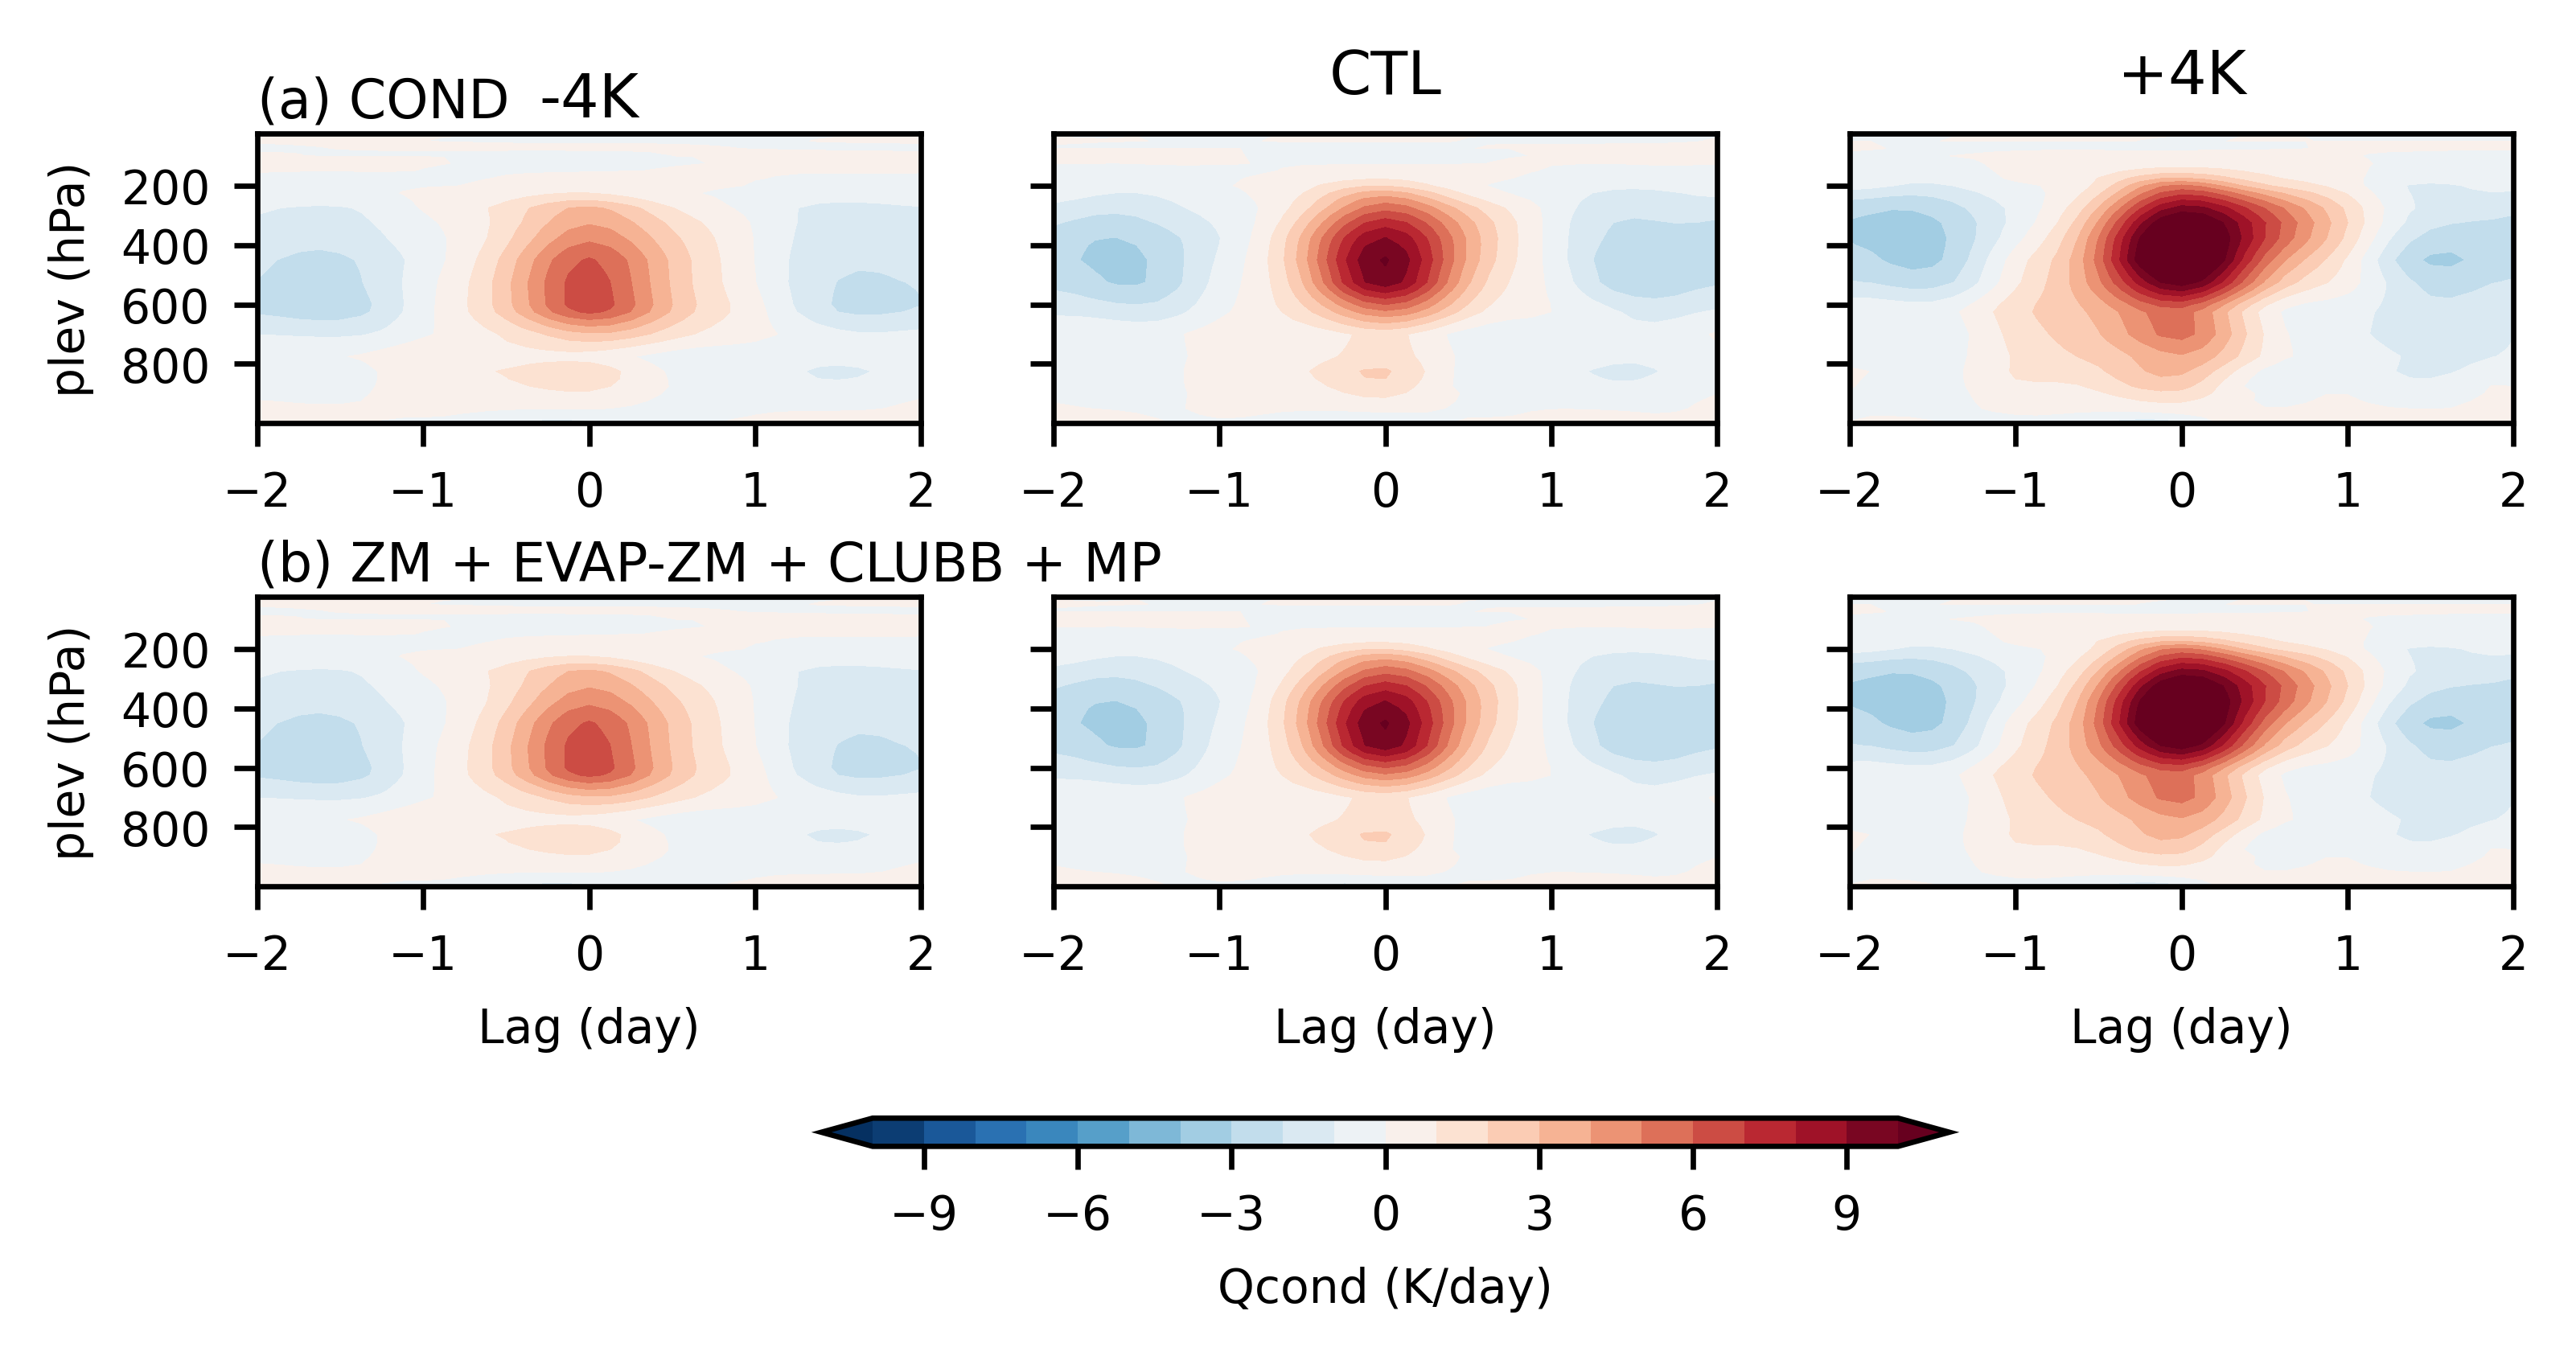

In [8]:
# Check if the sum of the below is Qcond
Q_sum_lag_plev = Q_ZM_lag_plev+Q_CLUBB_lag_plev+Q_MP_lag_plev+EVAPT_ZM_lag_plev

# Plot Qcond_lag_plev vs. Qsum_lag_plev
title_list = list(['-4K','CTL','+4K'])
print(np.shape(xx))

V_list = list(['Qcond','Q_sum'])
row_list = list(['(a) COND','(b) ZM + EVAP-ZM + CLUBB + MP'])
total = list(['','_tot'])
is_total = 0
if is_total == 0:
    clev = np.arange(-10,11,1)
else:
    clev = np.arange(-10,11,1)

font = 7
fig,axes = plt.subplots(2,3,figsize=(5.5, 3),dpi=600)
plt.subplots_adjust(left=0.1,right=0.95,top=0.9,bottom=0.1,wspace=0.2, hspace=0.6)
plt.rcParams.update({'font.size': font})
for irow in range(0,2):
    V = globals()[V_list[irow]+total[is_total]+'_lag_plev']
    for icase in range(0,3):
        plt.subplot(2,3,icase+1+irow*3)
        if irow == 0:
            plt.title(title_list[icase], fontsize=9)
        if icase == 0:
            plt.title(row_list[irow], pad=2.5, loc='left',fontsize=8)
        cf = plt.contourf( xx, yy, V[:,:,icase].T, levels=clev, cmap='RdBu_r', extend='both' )
        ax = plt.gca()
        if irow == 1:
            plt.xlabel('Lag (day)')
        plt.yticks(np.arange(200,1000,200))
        plt.gca().invert_yaxis()
        plt.tick_params(bottom=True,top=False,left=True,right=False)
        
        if icase == 0:
            plt.tick_params(labelbottom=True,labeltop=False,labelleft=True,labelright=False)
            ax.set_ylabel('plev (hPa)',fontsize=font)
        else:
            plt.tick_params(labelbottom=True,labeltop=False,labelleft=False,labelright=False)

        plt.xlim([-2,2])
        if icase == 2 and irow==1:
            cb = plt.colorbar(cf, ax = axes[:,:], orientation = 'horizontal', shrink=.5, aspect=40,pad=0.2) 
            cb.set_label('Qcond (K/day)')
            cb.ax.tick_params(labelsize=7)
            #cb.set_ticks(ticks)
plt.savefig(figdir+'Fig1_Q1_lag_plev_test_sum.png',dpi=600)  
plt.show()

In [7]:
# 2. load other DTCOND TENDENCY (melting)
calc_kwcomposite_melt = 0
if calc_kwcomposite_melt == 1:
    for icase in range(0, 3):
        CASENAME       = CASENAME_LIST2[icase]+'_DTCOND'
        output_dir_new = dir_out+'output_data/'+CASENAME+'/'
        print(CASENAME)
        
        # Load precip ano
        data          = np.load(output_dir_new+'precip_kw.npz')
        pr_ano        = data['pr_kwproj_ano_short']
        time_pr       = data['time_pr']
        lon        = data['lon']
        ilon        = np.argwhere(lon==180).squeeze()
        
        # Load melting
        data = np.load(output_dir_new+'ZM_scheme.npz')
        MELTSDT_ref = data['MELTSDT_ano'][time_pr[0]:time_pr[-1]+1,:,ilon]/Cp*s2d
        #ZMMD_ref    = data['ZMMD_ano'][time_pr[0]:time_pr[-1]+1,:,ilon]*s2d
        #ZMMU_ref    = data['ZMMU_ano'][time_pr[0]:time_pr[-1]+1,:,ilon]*s2d
        ZMEIHEAT_ref = data['ZMEIHEAT_ano'][time_pr[0]:time_pr[-1]+1,:,ilon]/Cp*s2d
    
        data = np.load(output_dir_new+'Microphysics_scheme.npz')
        MPDI2P_ref = data['MPDI2P_ano'][time_pr[0]:time_pr[-1]+1,:,ilon]
        MPDI2V_ref = data['MPDI2V_ano'][time_pr[0]:time_pr[-1]+1,:,ilon]
        MPDI2W_ref = data['MPDI2W_ano'][time_pr[0]:time_pr[-1]+1,:,ilon]
        plev = data['plev']
        nlev = np.size(plev)

        # Calculate lag-regression
        nt          = np.size(pr_ano, 0)
        lag_max_day = 5
        lag         = lag_max_day*8 # how many snapshots of time to calculate the lag-regression
        lags        = np.arange(-lag, lag+1, 1)
        
        pr_ref      = pr_ano[:,ilon]
        del pr_ano
        
        ntk = np.zeros([nt*2+1])
        ntk[0:nt+1] = np.arange(0,nt+1)
        ntk[nt+1:] = np.arange(nt-1,-1,-1)
        ntk = ntk[nt-lag:nt+lag+1]
        #print(ntk)
        
        for ilev in range(0,nlev):
            if ilev == 0 and icase==0:
                MELTSDT_lag_plev   = np.empty([2*lag+1, nlev, 3])
                ZMEIHEAT_lag_plev  = np.empty([2*lag+1, nlev, 3])
                MPDI2P_lag_plev  = np.empty([2*lag+1, nlev, 3])
                MPDI2V_lag_plev  = np.empty([2*lag+1, nlev, 3])
                MPDI2W_lag_plev  = np.empty([2*lag+1, nlev, 3])
            tmp = np.correlate( MELTSDT_ref[:,ilev], pr_ref, mode='full')
            MELTSDT_lag_plev[:,ilev,icase] = tmp[nt-1-lag:nt-1+lag+1]/ntk
            #
            tmp = np.correlate( ZMEIHEAT_ref[:,ilev], pr_ref, mode='full')
            ZMEIHEAT_lag_plev[:,ilev,icase] = tmp[nt-1-lag:nt-1+lag+1]/ntk
            #
            tmp = np.correlate( MPDI2P_ref[:,ilev], pr_ref, mode='full')
            MPDI2P_lag_plev[:,ilev,icase] = tmp[nt-1-lag:nt-1+lag+1]/ntk
            #
            tmp = np.correlate(MPDI2V_ref[:,ilev], pr_ref, mode='full')
            MPDI2V_lag_plev[:,ilev,icase] = tmp[nt-1-lag:nt-1+lag+1]/ntk
            #
            tmp = np.correlate( MPDI2W_ref[:,ilev], pr_ref, mode='full')
            MPDI2W_lag_plev[:,ilev,icase] = tmp[nt-1-lag:nt-1+lag+1]/ntk
    
        xx, yy = np.meshgrid(lags/8, plev)
        np.savez(output_dir_new+'ZM_MP_lag_plev.npz',MELTSDT_lag_plev=MELTSDT_lag_plev,\
             ZMEIHEAT_lag_plev=ZMEIHEAT_lag_plev, MPDI2P_lag_plev=MPDI2P_lag_plev, MPDI2V_lag_plev=MPDI2V_lag_plev,\
             MPDI2W_lag_plev=MPDI2W_lag_plev, lags=lags, plev=plev, xx=xx, yy=yy)
else:
    for icase in range(2, 3):
        CASENAME       = CASENAME_LIST2[icase]+'_DTCOND'
        output_dir_new = dir_out+'output_data/'+CASENAME+'/'
        data = np.load(output_dir_new+'ZM_MP_lag_plev.npz')
        MELTSDT_lag_plev    = data['MELTSDT_lag_plev']
        ZMEIHEAT_lag_plev   = data['ZMEIHEAT_lag_plev']
        MPDI2P_lag_plev     = data['MPDI2P_lag_plev']
        MPDI2V_lag_plev     = data['MPDI2V_lag_plev']
        MPDI2W_lag_plev     = data['MPDI2W_lag_plev']
        xx   = data['xx']
        yy   = data['yy']
        lags = data['lags']
        plev = data['plev']
        
    np.savez(output_dir_all+'ZM_MP_lag_plev.npz',MELTSDT_lag_plev=MELTSDT_lag_plev,\
             ZMEIHEAT_lag_plev=ZMEIHEAT_lag_plev, MPDI2P_lag_plev=MPDI2P_lag_plev, MPDI2V_lag_plev=MPDI2V_lag_plev,\
             MPDI2W_lag_plev=MPDI2W_lag_plev, lags=lags, plev=plev, xx=xx, yy=yy)

In [9]:
# 2. lOAD EACH dtcond tendency (not anomaly)
calc_kwcomposite_total_dt = 0
if calc_kwcomposite_total_dt == 1:
    for icase in range(2, 3):
    
        CASENAME       = CASENAME_LIST2[icase]+'_'+CASENAME_LONG_LIST[icase]
        output_dir     = dir_out+'output_data/'+CASENAME+'/'
        print(CASENAME)

        # Load precip ano
        data          = np.load(output_dir+'precip_kw.npz')
        pr_ano        = data['pr_kwproj_ano_short'] # This is anomaly without 10-day low pass variabiltiy
        time_pr       = data['time_pr']
        
        # Load Q_ano
        data       = np.load(output_dir+'dTdt_each_term.npz')
        plev       = data['plev']
        lon        = data['lon']
        nlev       = np.size(plev)
        ilon        = np.argwhere(lon==180).squeeze()

        Qcond_ref  = data['DTCOND_proj'][time_pr[0]:time_pr[-1]+1,:,ilon]*s2d
        Q_ZM_ref     = data['ZMDT_proj'][time_pr[0]:time_pr[-1]+1,:,ilon]*s2d
        EVAPT_ZM_ref = data['EVAPTZM_proj'][time_pr[0]:time_pr[-1]+1,:,ilon]*s2d
        Q_CLUBB_ref  = data['STEND_CLUBB_proj'][time_pr[0]:time_pr[-1]+1,:,ilon]*s2d
        Q_MP_ref     = data['MPDT_proj'][time_pr[0]:time_pr[-1]+1,:,ilon]*s2d
    
        # Calculate lag-regression
        nt          = np.size(pr_ano, 0)
        lag_max_day = 5
        lag         = lag_max_day*8 # how many snapshots of time to calculate the lag-regression
        lags        = np.arange(-lag, lag+1, 1)
        
        pr_ref      = pr_ano[:,ilon]
        del pr_ano
        
        ntk = np.zeros([nt*2+1])
        ntk[0:nt+1] = np.arange(0,nt+1)
        ntk[nt+1:] = np.arange(nt-1,-1,-1)
        ntk = ntk[nt-lag:nt+lag+1]
        #print(ntk)
        
        for ilev in range(0,nlev):
            if ilev == 0 and icase==0:
                Qcond_tot_lag_plev = np.empty([2*lag+1, nlev, 3])
                Q_ZM_tot_lag_plev  = np.empty([2*lag+1, nlev, 3])
                Q_CLUBB_tot_lag_plev  = np.empty([2*lag+1, nlev, 3])
                Q_MP_tot_lag_plev  = np.empty([2*lag+1, nlev, 3])
                EVAPT_ZM_tot_lag_plev = np.empty([2*lag+1, nlev, 3])
            tmp = np.correlate( Qcond_ref[:,ilev], pr_ref, mode='full')
            Qcond_tot_lag_plev[:,ilev,icase] = tmp[nt-1-lag:nt-1+lag+1]/ntk
            #
            tmp = np.correlate( Q_ZM_ref[:,ilev], pr_ref, mode='full')
            Q_ZM_tot_lag_plev[:,ilev,icase] = tmp[nt-1-lag:nt-1+lag+1]/ntk
            #
            tmp = np.correlate( Q_CLUBB_ref[:,ilev], pr_ref, mode='full')
            Q_CLUBB_tot_lag_plev[:,ilev,icase] = tmp[nt-1-lag:nt-1+lag+1]/ntk
            #
            tmp = np.correlate( Q_MP_ref[:,ilev], pr_ref, mode='full')
            Q_MP_tot_lag_plev[:,ilev,icase] = tmp[nt-1-lag:nt-1+lag+1]/ntk
            #
            tmp = np.correlate( EVAPT_ZM_ref[:,ilev], pr_ref, mode='full')
            EVAPT_ZM_tot_lag_plev[:,ilev,icase] = tmp[nt-1-lag:nt-1+lag+1]/ntk
    
    xx, yy = np.meshgrid(lags/8, plev)
    np.savez(output_dir_all+'DT_decomp_lag_plev_total_not-anomaly.npz', Qcond_tot_lag_plev=Qcond_tot_lag_plev,\
             Q_ZM_tot_lag_plev=Q_ZM_tot_lag_plev, Q_CLUBB_tot_lag_plev=Q_CLUBB_tot_lag_plev,\
             Q_MP_tot_lag_plev=Q_MP_tot_lag_plev,\
             EVAPT_ZM_tot_lag_plev=EVAPT_ZM_tot_lag_plev, lags=lags, plev=plev, xx=xx, yy=yy)
else:
    data = np.load(output_dir_all+'DT_decomp_lag_plev_total_not-anomaly.npz')
    Qcond_tot_lag_plev    = data['Qcond_tot_lag_plev']
    Q_ZM_tot_lag_plev     = data['Q_ZM_tot_lag_plev']
    Q_CLUBB_tot_lag_plev  = data['Q_CLUBB_tot_lag_plev']
    Q_MP_tot_lag_plev     = data['Q_MP_tot_lag_plev']
    EVAPT_ZM_tot_lag_plev = data['EVAPT_ZM_tot_lag_plev']
    xx   = data['xx']
    yy   = data['yy']
    lags = data['lags']
    plev = data['plev']

In [10]:
for icase in range(0, 3):
    
    CASENAME       = CASENAME_LIST2[icase]+'_'+CASENAME_LONG_LIST[icase]
    output_dir     = dir_out+'output_data/'+CASENAME+'/'
    print(CASENAME)

    # Load precip ano
    data          = np.load(output_dir+'precip_kw.npz')
    pr_ano        = data['pr_kwproj_ano_short'] # This is anomaly without 10-day low pass variabiltiy
    #print(np.shape(pr_ano))
    if icase == 0:
        pr_var = np.empty([3])
    pr_var[icase] = np.var(pr_ano)
print(pr_var)

SST_AQP3_Qobs_27_-4K_3h_20y_CLUBB_new
SST_AQP3_Qobs_27_3h_20y_CLUBB_new_uv_tendency
SST_AQP3_Qobs_27_4K_3h_20y_CLUBB_new
[11.8574259  15.13939454 22.75895116]


In [11]:
# Load melting level
# 1. load mean state T
for icase in range(0,3):

    if icase != 1:
        CASENAME       = CASENAME_LIST2[icase]+'_3h_20y_CLUBB_new'
    else:
        CASENAME       = CASENAME_LIST2[icase]+'_3h_20y_CLUBB_new_uv_tendency'
    output_dir = dir_out+'output_data/'+CASENAME+'/'
    data = np.load(output_dir+'QTUVZq.npz')
    plev_m = data['plev']
    nlev = np.size(plev_m)
    if icase == 0:
        Tm = np.empty([nlev, 3])
    Tm[:,icase] = data['Tm']-273.15

for icase in range(0,3):
    if icase == 0:
        ilev_melt = np.zeros([3]).astype('int')
    #ilev_melt[icase] = int(np.argwhere(np.abs(Tm_10SN[:,icase])==np.min(np.abs(Tm_10SN[:,icase]))).squeeze())
    ilev_melt[icase] = int(np.argwhere(np.abs(Tm[:,icase])==np.min(np.abs(Tm[:,icase]))).squeeze())
print(plev_m[ilev_melt])

[650 575 525]


In [29]:
print(np.min(Qcond_tot_lag_plev[:,:,:]), np.max(Qcond_tot_lag_plev[:,:,:]))
print(np.min(Qcond_lag_plev[:,:,:]), np.max(Qcond_lag_plev[:,:,:]))

-3.9117071758153235 14.519075669240316
-3.9212030525331376 13.581130244866149


In [14]:
print(np.min(MELTSDT_lag_plev), np.max(MELTSDT_lag_plev))
print(np.min(ZMEIHEAT_lag_plev), np.max(ZMEIHEAT_lag_plev))
print(np.min(MPDI2P_lag_plev), np.max(MPDI2P_lag_plev))
print(np.min(MPDI2V_lag_plev), np.max(MPDI2V_lag_plev))
print(np.min(MPDI2W_lag_plev), np.max(MPDI2W_lag_plev))

-2.8443258926211645 1.0288817309127813
-1.8775993114466623 0.8712185194789713
-9.115609099570061e-09 3.2748536962321477e-09
-2.3200202444966223e-09 6.871045371415559e-09
-1.2754144477856627e-09 3.539114515576678e-09


In [16]:
print(plev_m)

[  25   50   75  100  125  150  175  200  225  250  275  300  325  350
  375  400  425  450  475  500  525  550  575  600  625  650  675  700
  725  750  775  800  825  850  875  900  925  950  975 1000]


In [13]:
# Load melting 
data = np.load(output_dir_all+'ZM_MP_lag_plev.npz')
MELTSDT_lag_plev = data['MELTSDT_lag_plev']

/glade/u/ssg/ch/usr/jupyterhub/envs/cmip6-201910a/lib/python3.7/site-packages/ipykernel_launcher.py:42: UserWarning: No contour levels were found within the data range.


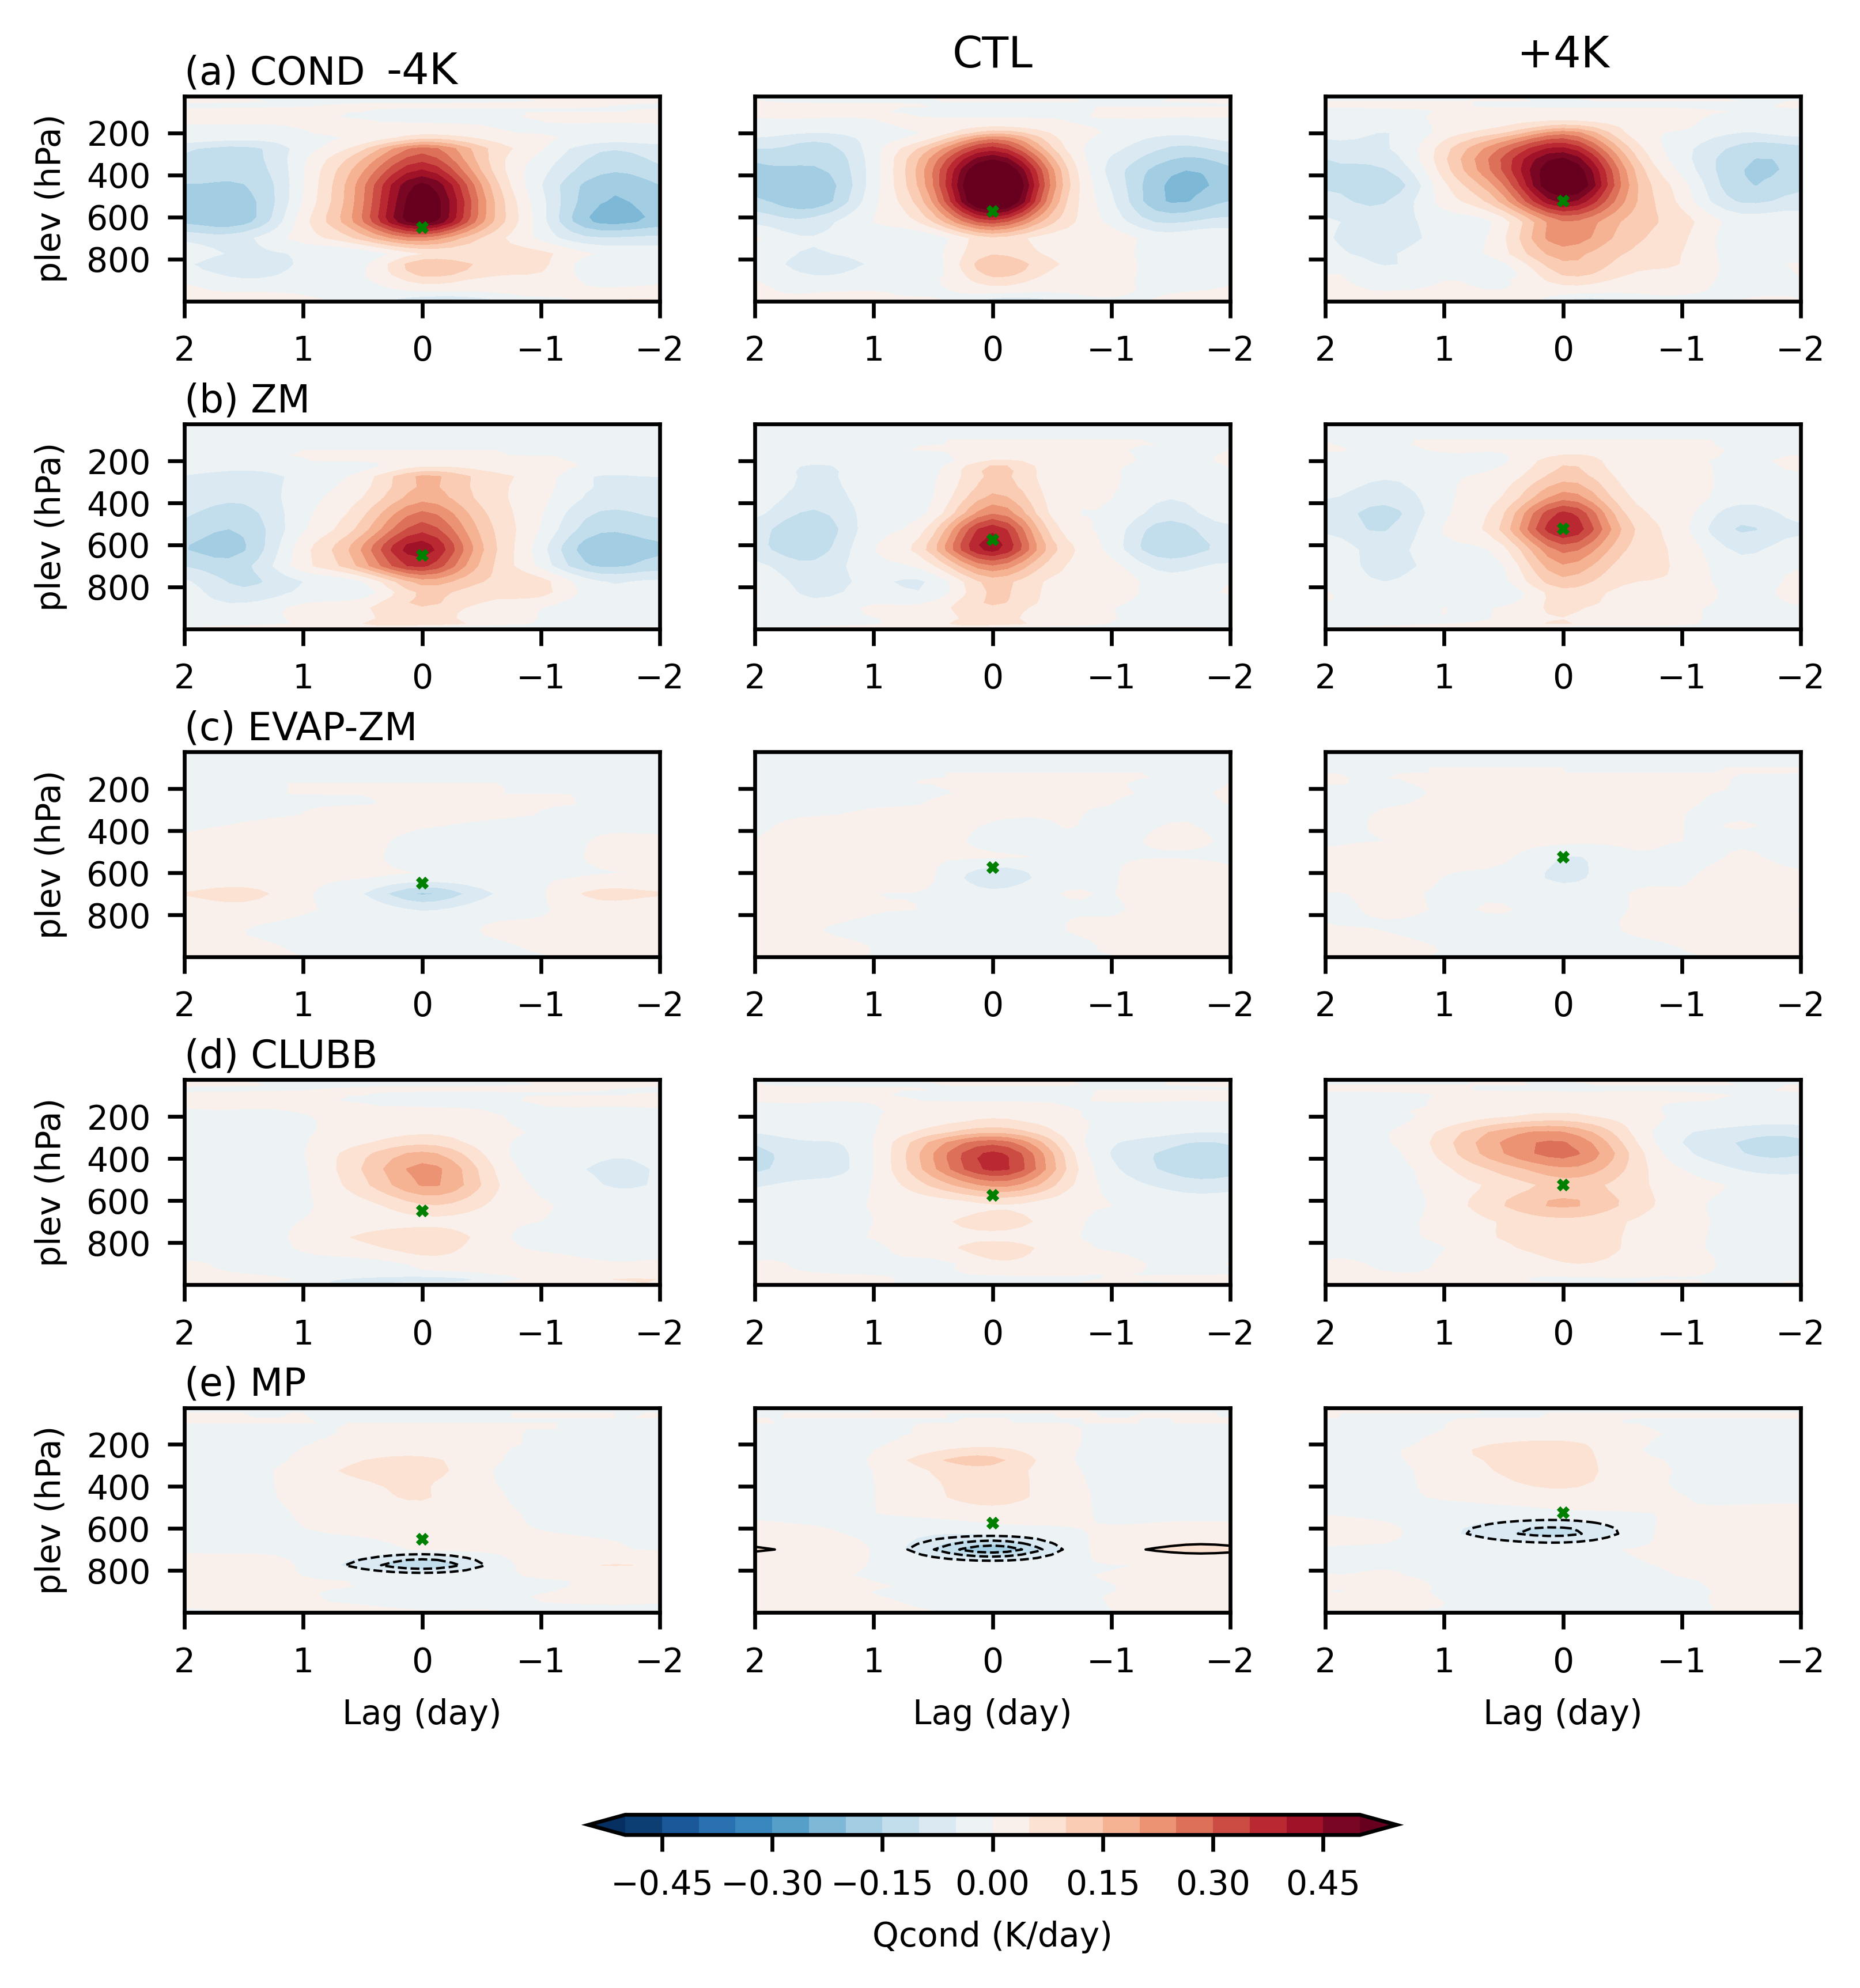

In [14]:
# Plot Qcond_lag_plev
title_list = list(['-4K','CTL','+4K'])

plot_Qcond_melt = 0 # 0 or 1
total = list(['','_tot'])
is_total = 0 # or 1

if plot_Qcond_melt == 0:
    V_list = list(['Qcond','Q_ZM','EVAPT_ZM','Q_CLUBB','Q_MP'])
    row_list = list(['(a) COND','(b) ZM','(c) EVAP-ZM','(d) CLUBB','(e) MP'])
    clev = np.arange(-10,11,1)/20
    clev_n = np.arange(-10,0,1)/20
    clev_p = np.arange(1,11,1)/20
else:
    V_list = list(['MELTSDT','ZMEIHEAT','MPDI2P','MPDI2V','MPDI2W'])
    row_list = list(['(a) MELT','(b) ZMEIHEAT','(c) MPDI2P','(d) MPDI2V','(e) MPDI2W']) 

font = 7
fig,axes = plt.subplots(5,3,figsize=(5.5, 6.5),dpi=600)
plt.subplots_adjust(left=0.1,right=0.95,top=0.95,bottom=0.05,wspace=0.2, hspace=0.6)
plt.rcParams.update({'font.size': font})
for irow in range(0,5):
    V = globals()[V_list[irow]+total[is_total]+'_lag_plev']
    if plot_Qcond_melt == 1:
        if irow == 0 or irow == 1:
            clev = np.arange(-3,3.3,0.3)
        elif irow == 2 or irow == 3 or irow == 4:
            clev = np.arange(-8,9,1)*10**(-9)
    for icase in range(0,3):
        V2 = V[:,:,icase]/pr_var[icase]
        plt.subplot(5,3,icase+1+irow*3)
        if irow == 0:
            plt.title(title_list[icase], pad=6, fontsize=9)
        if icase == 0:
            plt.title(row_list[irow], pad=2.5, loc='left',fontsize=8)
        #cf = plt.contourf( xx, yy, Qcond_lag_plev[:,:,icase].T, levels=clev, cmap=get_cmap(RWB), extend='both' )
        cf = plt.contourf( xx, yy, V2.T, levels=clev, cmap='RdBu_r', extend='both' )
        if plot_Qcond_melt == 0 and irow == 4:
            cn_n = plt.contour( xx, yy, MELTSDT_lag_plev[:,:,icase].T/pr_var[icase], levels=clev_n, linestyles='dashed',\
                               colors='k',linewidths=0.5)
            cn_p = plt.contour( xx, yy, MELTSDT_lag_plev[:,:,icase].T/pr_var[icase], levels=clev_p,\
                               colors='k',linewidths=0.5)
        plt.plot( [0,0],[plev_m[ilev_melt[icase]],plev_m[ilev_melt[icase]]], 'green',marker='x', markersize=2)#, linewidth=0.3)
        ax = plt.gca()
        if irow == 4:
            plt.xlabel('Lag (day)')
        plt.yticks(np.arange(200,1000,200))
        plt.gca().invert_yaxis()
        plt.tick_params(bottom=True,top=False,left=True,right=False)

        if icase == 0:
            plt.tick_params(labelbottom=True,labeltop=False,labelleft=True,labelright=False)
            ax.set_ylabel('plev (hPa)',fontsize=font)
        else:
            plt.tick_params(labelbottom=True,labeltop=False,labelleft=False,labelright=False)
        #elif icase == 1:
        #    plt.tick_params(labelbottom=True,labeltop=False,labelleft=False,labelright=False)
        #elif icase == 2:
        #   plt.tick_params(labelbottom=True,labeltop=False,labelleft=False,labelright=False)
        
        #plt.xlim([-4,4])
        plt.xlim([-2,2])
        plt.xticks(np.arange(-2,3,1))
        plt.gca().invert_xaxis()
        if plot_Qcond_melt == 0:
            if icase == 2 and irow==4:
                cb = plt.colorbar(cf, ax = axes[:,:], orientation = 'horizontal', shrink=.5, aspect=40,pad=0.1) 
                cb.set_label('Qcond (K/day)')
                cb.ax.tick_params(labelsize=7)
                #cb.set_ticks(ticks)
        else:
            if icase == 2:
                cb = plt.colorbar(cf, ax = axes[irow,:], orientation = 'vertical', shrink=.9, aspect=20,pad=0.05) 
                cb.ax.tick_params(labelsize=7)            
if plot_Qcond_melt == 0:
    plt.savefig(figdir+'Fig1_Q1_lag_plev_+-2day'+total[is_total]+'.png',dpi=600)  
else:
    plt.savefig(figdir+'Fig1_Q1_lag_plev_melt.png',dpi=600)  
plt.show()

In [33]:
# Calcualte assymetry to best capture the 2nd mode (Q in positive lag day - Q in negative lag day), 
# calculated wihtin +-1 day
ilag_0 = np.argwhere(lags==0).squeeze()
ilag_min = np.argwhere(lags==-4).squeeze()
ilag_max = np.argwhere(lags==4).squeeze()

Qcond_asy     = 0.5*( np.mean(Qcond_lag_plev[ilag_0:ilag_max+1,:,:],0) -np.mean(Qcond_lag_plev[ilag_min:ilag_0+1,:,:],0) )
Q_ZM_asy      = 0.5*( np.mean(Q_ZM_lag_plev[ilag_0:ilag_max+1,:,:],0)  -np.mean(Q_ZM_lag_plev[ilag_min:ilag_0+1,:,:],0) )
Q_CLUBB_asy   = 0.5*( np.mean(Q_CLUBB_lag_plev[ilag_0:ilag_max+1,:,:],0)-np.mean(Q_CLUBB_lag_plev[ilag_min:ilag_0+1,:,:],0) )
EVAPT_ZM_asy  = 0.5*( np.mean(EVAPT_ZM_lag_plev[ilag_0:ilag_max+1,:,:],0)-np.mean(EVAPT_ZM_lag_plev[ilag_min:ilag_0+1,:,:],0) )
Q_MP_asy      = 0.5*( np.mean(Q_MP_lag_plev[ilag_0:ilag_max+1,:,:],0)    -np.mean(Q_MP_lag_plev[ilag_min:ilag_0+1,:,:],0) )

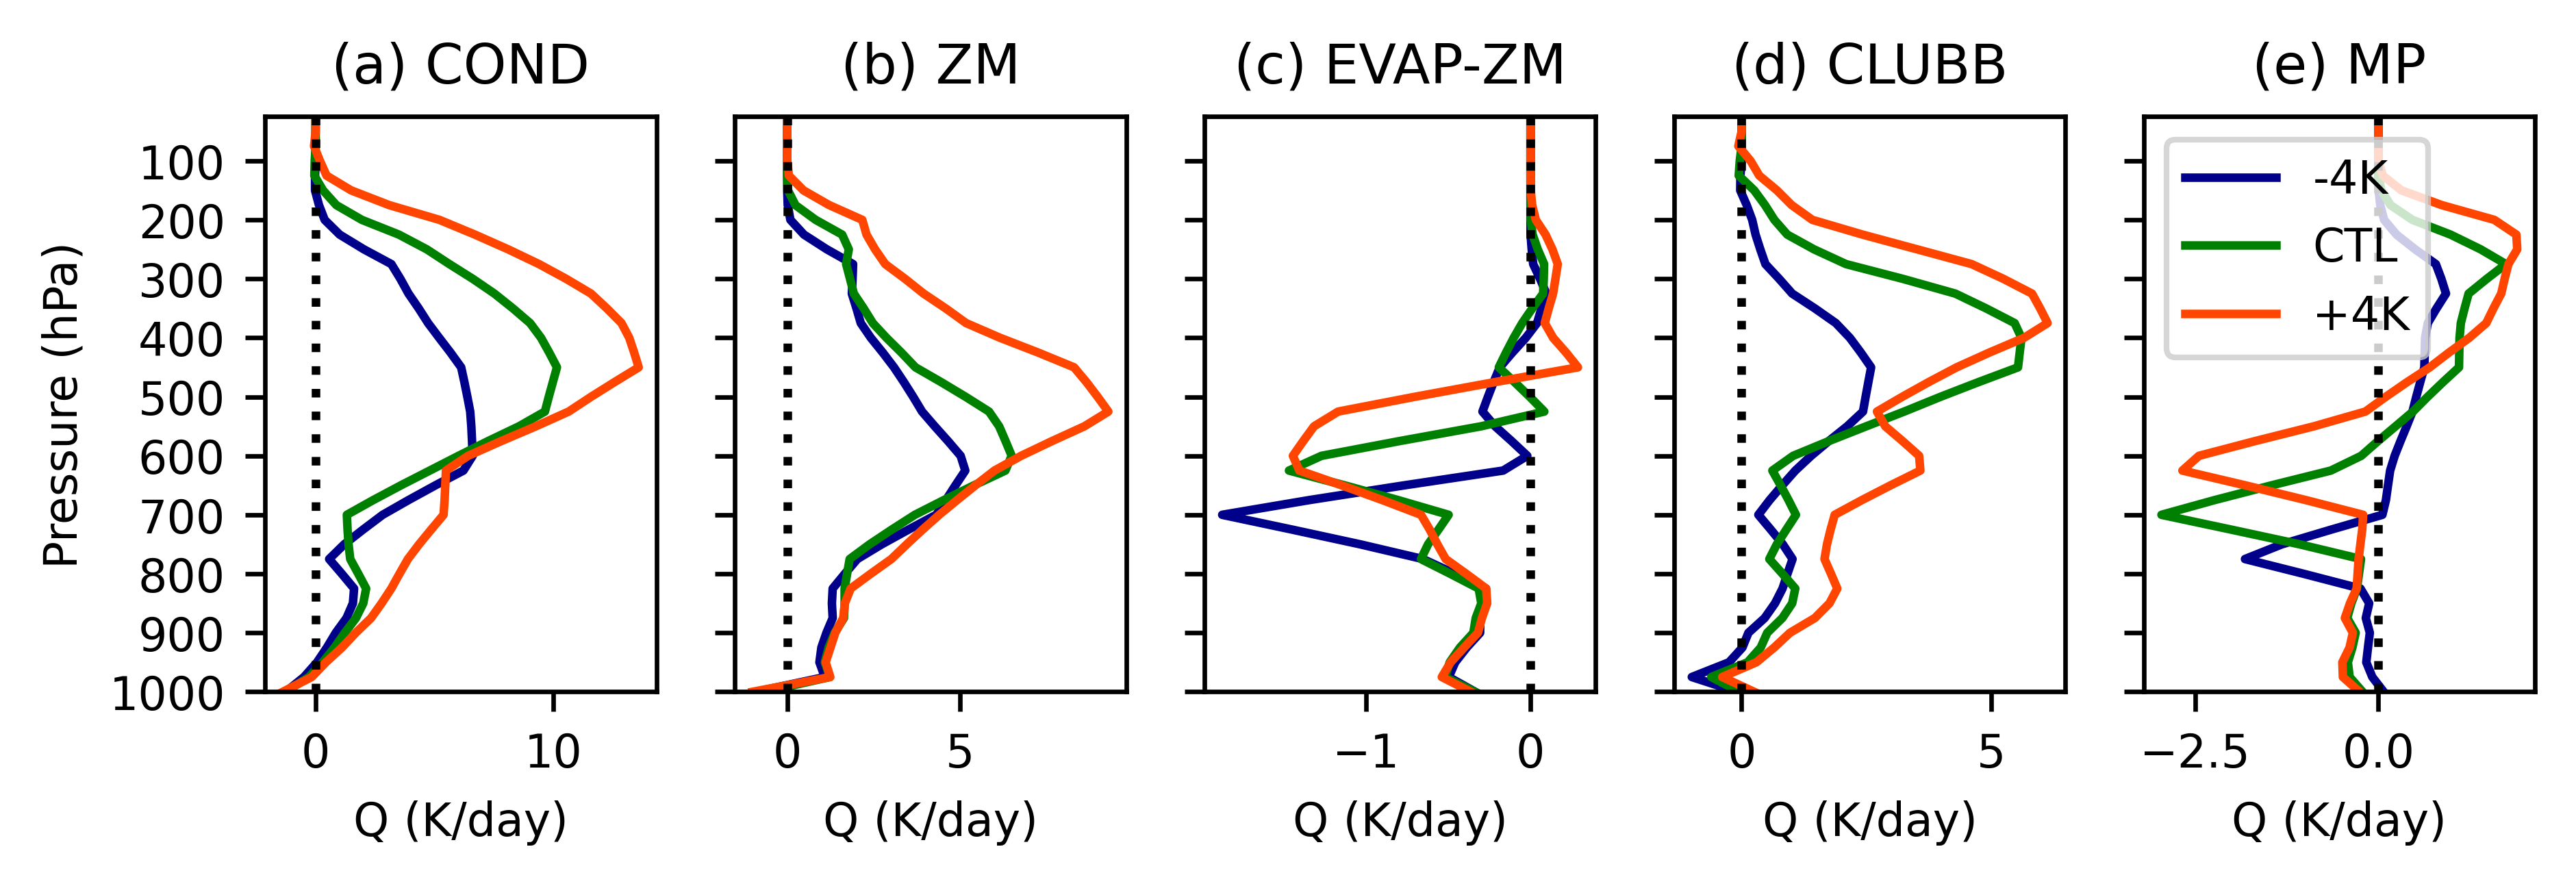

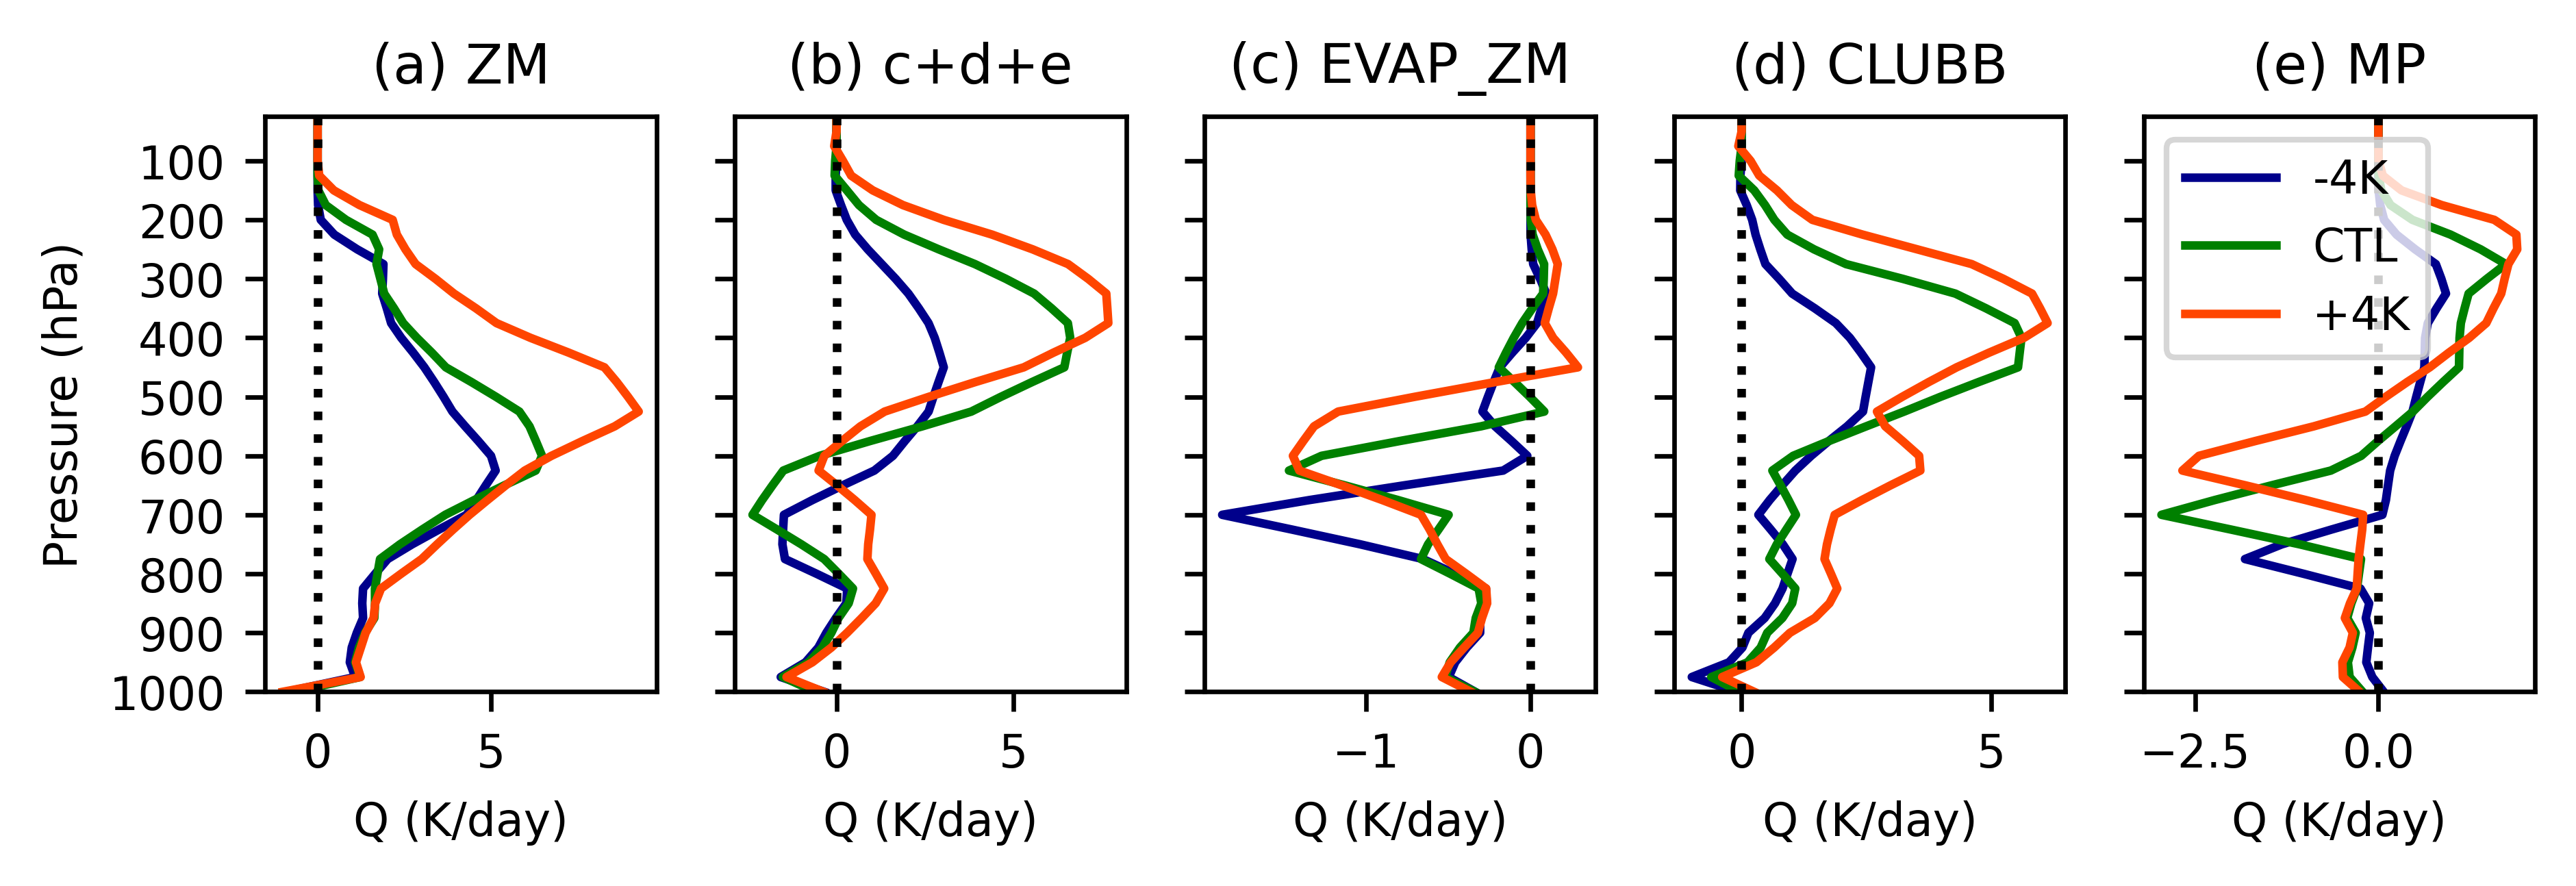

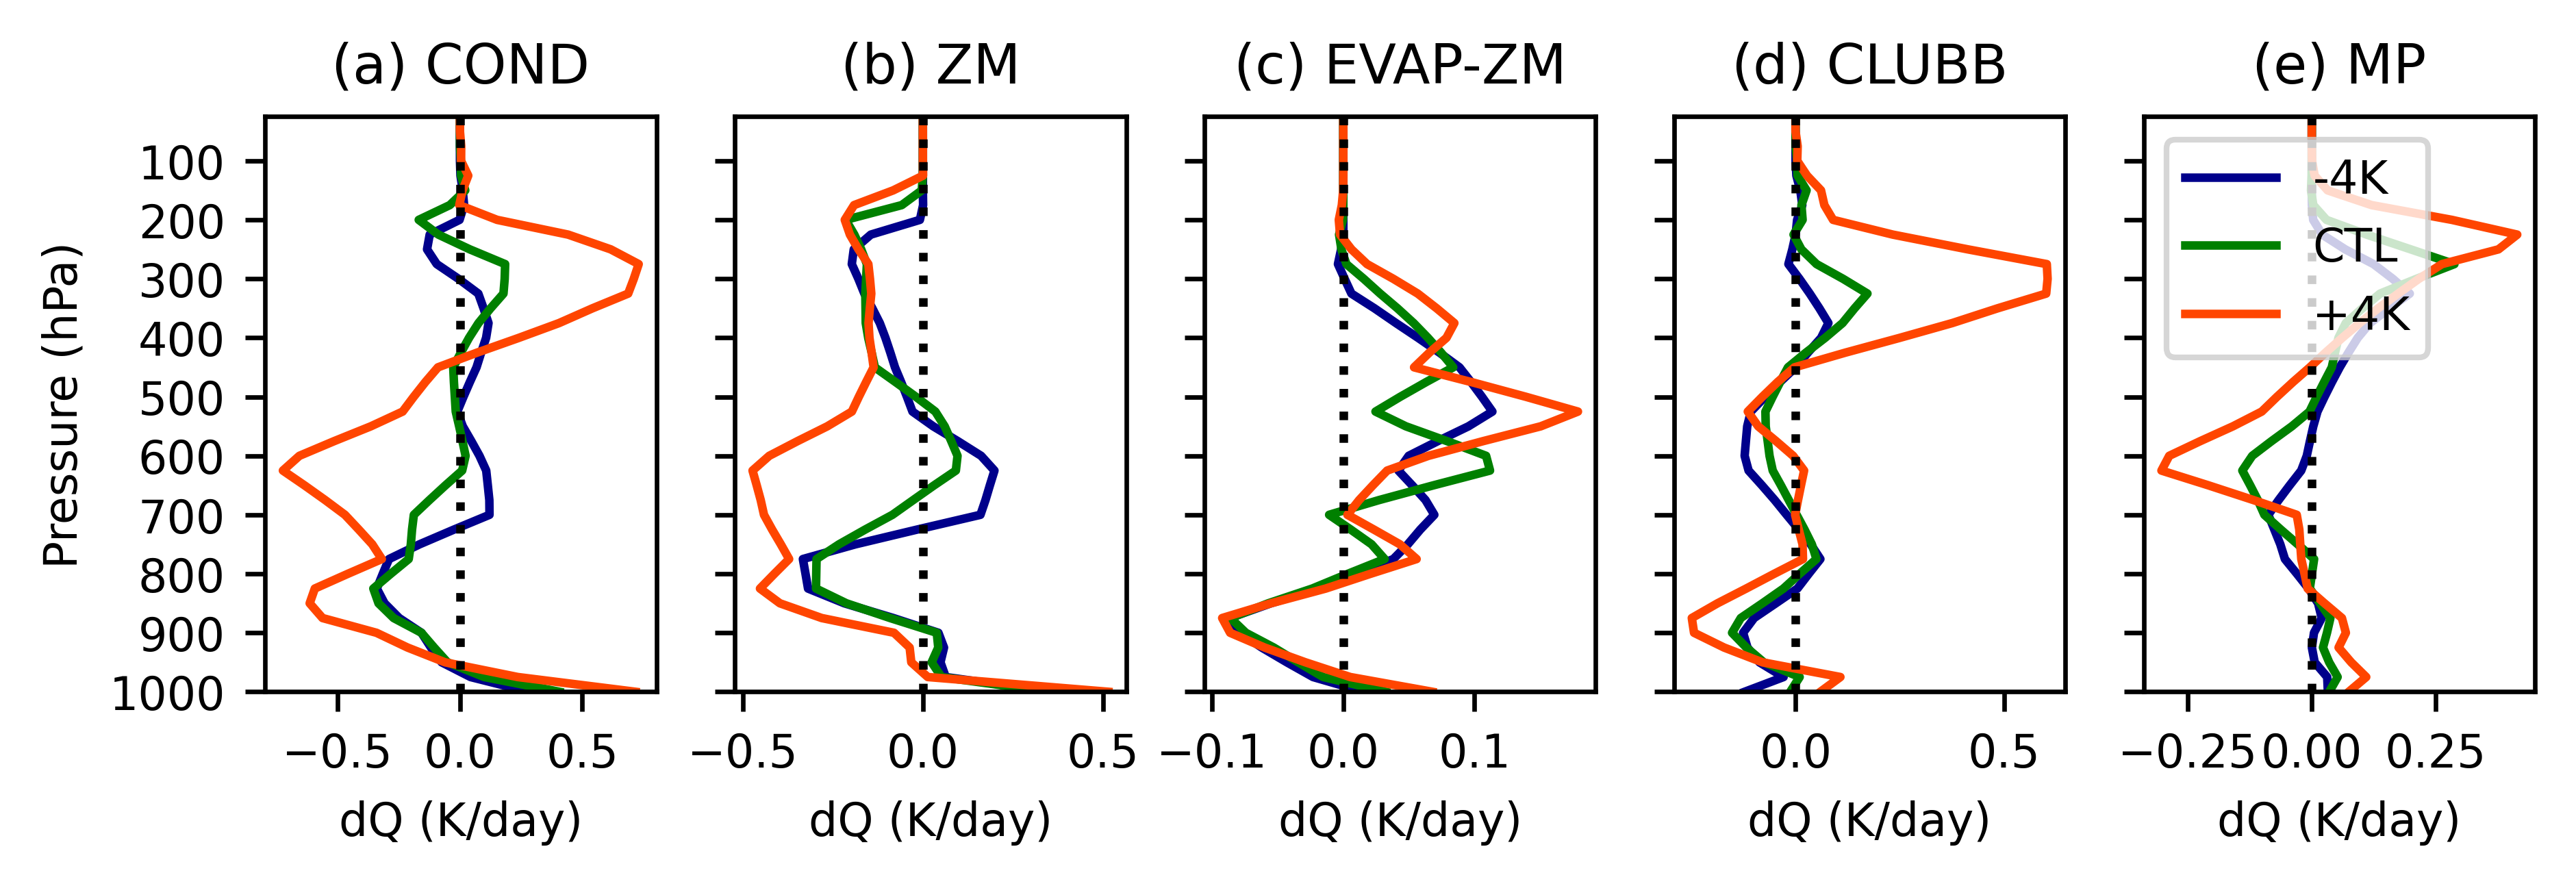

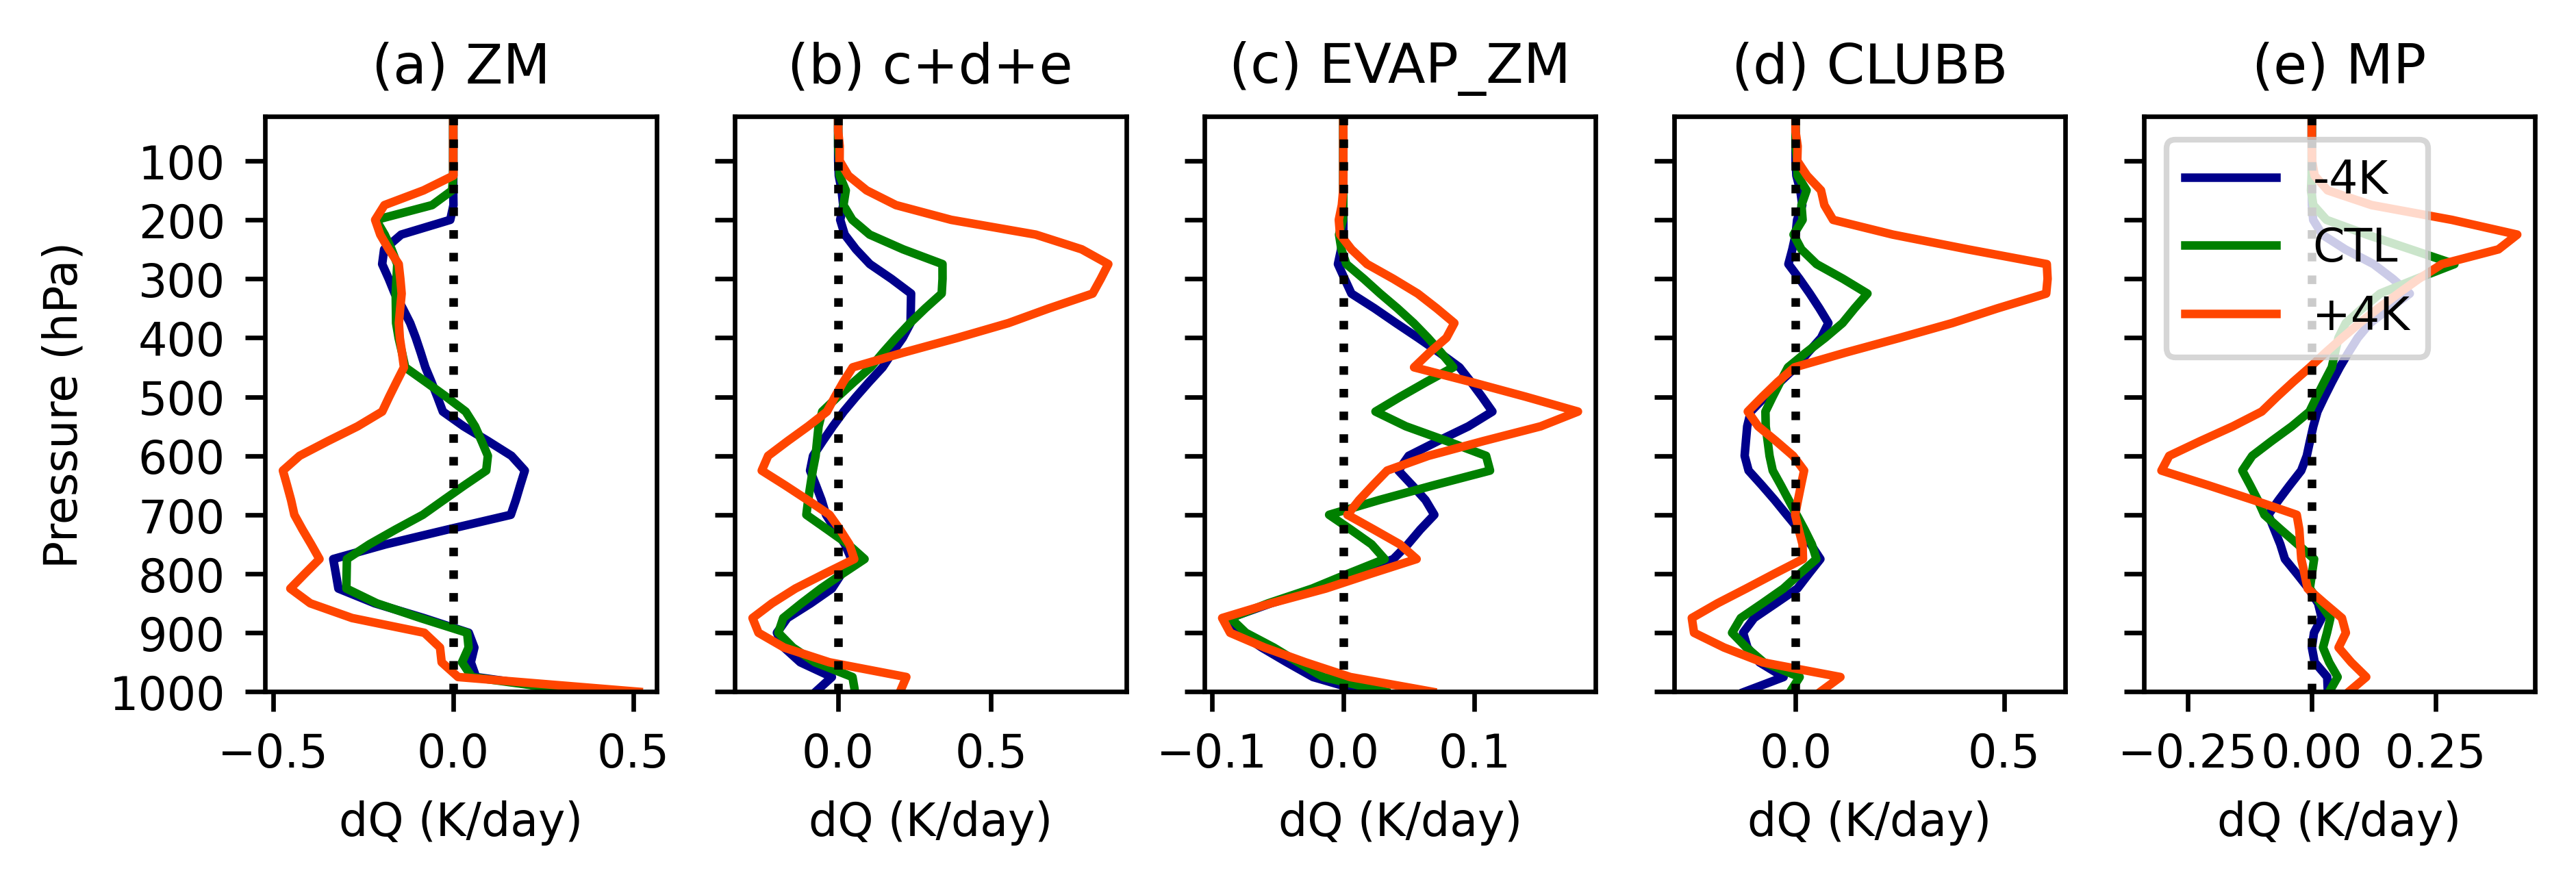

In [36]:
# 3. Check how the vertical structure above is realted to EOF
Qsum_noZM_lag_plev = EVAPT_ZM_lag_plev + Q_CLUBB_lag_plev + Q_MP_lag_plev
Qsum_noZM_asy      = EVAPT_ZM_asy + Q_CLUBB_asy + Q_MP_asy
for iplt in range(0, 4):
    if iplt == 0 or iplt == 2:
        V_list = list(['Qcond','Q_ZM','EVAPT_ZM','Q_CLUBB','Q_MP'])
        row_list = list(['(a) COND','(b) ZM','(c) EVAP-ZM','(d) CLUBB','(e) MP'])
    elif iplt == 1 or iplt == 3:
        V_list = list(['Q_ZM','Qsum_noZM','EVAPT_ZM','Q_CLUBB','Q_MP'])
        row_list = list(['(a) ZM','(b) c+d+e','(c) EVAP_ZM','(d) CLUBB','(e) MP'])        
    fig,axes = plt.subplots(1,5,figsize=(6.5, 2),dpi=600)
    plt.subplots_adjust(left=0.1,right=0.95,top=0.9,bottom=0.2,wspace=0.2)
    plt.rcParams.update({'font.size': font})
    zero = np.zeros([nlev])
    
    for icol in range(0,5):
        if iplt == 0 or iplt == 1:
            V = globals()[V_list[icol]+'_lag_plev']
            V = V[ilag_0,:,:]
        elif iplt == 2 or iplt == 3:
            V = globals()[V_list[icol]+'_asy']
            
        plt.subplot(1,5,icol+1)
        plt.title( row_list[icol] )
        plt.plot( V[:,0], plev, color='darkblue')
        plt.plot( V[:,1], plev, color='green')
        plt.plot( V[:,2], plev, color='orangered')
        plt.plot( zero, plev, 'k:')
        plt.ylim( np.min(plev), np.max(plev) )
        if icol == 4:
            plt.legend(['-4K','CTL','+4K'], loc='upper left')
        plt.yticks(np.arange(100,1100,100))
        if icol == 0:
            plt.tick_params(labelbottom=True,labeltop=False,labelleft=True,labelright=False)
            plt.ylabel('Pressure (hPa)')
        else:
            plt.tick_params(labelbottom=True,labeltop=False,labelleft=False,labelright=False)
        plt.gca().invert_yaxis()
        if iplt == 0 or iplt == 1:
            plt.xlabel('Q (K/day)')
        elif iplt == 2 or iplt == 3:
            plt.xlabel('dQ (K/day)')
    if iplt == 0:
        plt.savefig(figdir+'Fig2_Q1_lag0_plev.png',dpi=600)  
    elif iplt == 1:
        plt.savefig(figdir+'Fig2_Q1_lag0_plev_sum.png',dpi=600)  
    elif iplt == 2:
        plt.savefig(figdir+'Fig3_Q1_+-0.5day_lag_asy_plev.png',dpi=600)  
    elif iplt == 3:
        plt.savefig(figdir+'Fig3_Q1_+-0.5day_lag_asy_plev_sum.png',dpi=600)  
    plt.show()

In [18]:
print(lags)

[-40 -39 -38 -37 -36 -35 -34 -33 -32 -31 -30 -29 -28 -27 -26 -25 -24 -23
 -22 -21 -20 -19 -18 -17 -16 -15 -14 -13 -12 -11 -10  -9  -8  -7  -6  -5
  -4  -3  -2  -1   0   1   2   3   4   5   6   7   8   9  10  11  12  13
  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31
  32  33  34  35  36  37  38  39  40]


In [ ]:
# Conclusion
# Overall, the second mode is mostly determined by EVAPT_ZM and Q_MP, and partially determined by CLUBB!

# The second mode peaks locate at 800 and 450 hPa in -4K, 
#                                 700 and 400 hPa in CTL
#                                 650 and 350 hPa in +4K
# The upper level peak roughly corresponds to the peak of CLUBB (mostly) and MP, due to condensation of stratiform
# The lower level peak roughly corresponds to the negative peak of MP (mostly) and EVAP_ZM, due to evaporation and melting 
#                                          and the positve peak of CLUBB, due to shallow cloud or congestus

# Note that the nodal point of MP is roughly the melting level

In [26]:
#####################################################
# Decompose each term to Q1 and Q2 structure (official, all lag days)
##################################################
nlags = np.size(lags)

# Load EOF from Q1 and Q2
data = np.load(output_dir_all_paper2+'EOF_all.npz') #,plev_ref=plev_ref, EOFQ1=EOFQ1, EOFQ2=EOFQ2, EOFU1=EOFU1, EOFU2=EOFU2)
EOFQ1 = data['EOFQ1']
EOFQ2 = data['EOFQ2']
plev_ref  = data['plev_ref']

# Progresses from negative lag day 0.5 to positve lag day 0.5
V_list = list(['Qcond','Q_ZM','EVAPT_ZM','Q_CLUBB','Q_MP'])
lag_target = np.array([-4, 0, 4])

for icase in range(0, 3):
    for ilag in range(0, np.size(lags)):
        if icase == 0 and ilag == 0:
            Qcond_lag_plev_EOF1    = np.empty([nlags, 3])
            Q_ZM_lag_plev_EOF1     = np.empty([nlags, 3])
            EVAPT_ZM_lag_plev_EOF1 = np.empty([nlags, 3])
            Q_CLUBB_lag_plev_EOF1  = np.empty([nlags, 3])
            Q_MP_lag_plev_EOF1     = np.empty([nlags, 3])
            Q_MELT_lag_plev_EOF1   = np.empty([nlags, 3])
            #
            Qcond_lag_plev_EOF2    = np.empty([nlags, 3])
            Q_ZM_lag_plev_EOF2     = np.empty([nlags, 3])
            EVAPT_ZM_lag_plev_EOF2 = np.empty([nlags, 3])
            Q_CLUBB_lag_plev_EOF2  = np.empty([nlags, 3])
            Q_MP_lag_plev_EOF2     = np.empty([nlags, 3])
            Q_MELT_lag_plev_EOF2   = np.empty([nlags, 3])

        ilevmin = np.argwhere(plev==75).squeeze()
        ilevmax = np.argwhere(plev==950).squeeze()

        tmp                                    = Qcond_lag_plev[ilag,ilevmin:ilevmax+1,icase]/pr_var[icase]
        Qcond_lag_plev_EOF1[ilag,icase]    = np.inner(tmp, EOFQ1[:,icase])#/np.inner(tmp, tmp)
        tmp                                    = Q_ZM_lag_plev[ilag,ilevmin:ilevmax+1,icase]/pr_var[icase]
        Q_ZM_lag_plev_EOF1[ilag,icase]     = np.inner(tmp, EOFQ1[:,icase])#/np.inner(tmp, tmp)
        tmp                                    = EVAPT_ZM_lag_plev[ilag,ilevmin:ilevmax+1,icase]/pr_var[icase]
        EVAPT_ZM_lag_plev_EOF1[ilag,icase] = np.inner(tmp, EOFQ1[:,icase])#/np.inner(tmp, tmp)
        tmp                                    = Q_CLUBB_lag_plev[ilag,ilevmin:ilevmax+1,icase]/pr_var[icase]
        Q_CLUBB_lag_plev_EOF1[ilag,icase]  = np.inner(tmp, EOFQ1[:,icase])#/np.inner(tmp, tmp)
        tmp                                    = Q_MP_lag_plev[ilag,ilevmin:ilevmax+1,icase]/pr_var[icase]
        Q_MP_lag_plev_EOF1[ilag,icase]     = np.inner(tmp, EOFQ1[:,icase])#/np.inner(tmp, tmp)
        tmp                                    = MELTSDT_lag_plev[ilag,ilevmin:ilevmax+1,icase]/pr_var[icase]
        Q_MELT_lag_plev_EOF1[ilag,icase]     = np.inner(tmp, EOFQ1[:,icase])#/np.inner(tmp, tmp)

        #
        tmp                                    = Qcond_lag_plev[ilag,ilevmin:ilevmax+1,icase]/pr_var[icase]
        Qcond_lag_plev_EOF2[ilag,icase]    = np.inner(tmp, EOFQ2[:,icase])#/np.inner(tmp, tmp)
        tmp                                    = Q_ZM_lag_plev[ilag,ilevmin:ilevmax+1,icase]/pr_var[icase] 
        Q_ZM_lag_plev_EOF2[ilag,icase]     = np.inner(tmp, EOFQ2[:,icase])#/np.inner(tmp, tmp)
        tmp                                    = EVAPT_ZM_lag_plev[ilag,ilevmin:ilevmax+1,icase]/pr_var[icase]
        EVAPT_ZM_lag_plev_EOF2[ilag,icase] = np.inner(tmp, EOFQ2[:,icase])#/np.inner(tmp, tmp)
        tmp                                    = Q_CLUBB_lag_plev[ilag,ilevmin:ilevmax+1,icase]/pr_var[icase]
        Q_CLUBB_lag_plev_EOF2[ilag,icase]  = np.inner(tmp, EOFQ2[:,icase])#/np.inner(tmp, tmp)
        tmp                                    = Q_MP_lag_plev[ilag,ilevmin:ilevmax+1,icase]/pr_var[icase]
        Q_MP_lag_plev_EOF2[ilag,icase]     = np.inner(tmp, EOFQ2[:,icase])#/np.inner(tmp, tmp)
        tmp                                    = MELTSDT_lag_plev[ilag,ilevmin:ilevmax+1,icase]/pr_var[icase]
        Q_MELT_lag_plev_EOF2[ilag,icase]     = np.inner(tmp, EOFQ2[:,icase])
        #
np.savez(output_dir_all_2+'DT_decomp_lag_plev_project-to-EOF.npz', \
         Qcond_lag_plev_EOF1=Qcond_lag_plev_EOF1, Q_ZM_lag_plev_EOF1=Q_ZM_lag_plev_EOF1, EVAPT_ZM_lag_plev_EOF1=EVAPT_ZM_lag_plev_EOF1,\
        Q_CLUBB_lag_plev_EOF1=Q_CL
         UBB_lag_plev_EOF1, Q_MP_lag_plev_EOF1=Q_MP_lag_plev_EOF1,\
         Qcond_lag_plev_EOF2=Qcond_lag_plev_EOF2, Q_ZM_lag_plev_EOF2=Q_ZM_lag_plev_EOF2, EVAPT_ZM_lag_plev_EOF2=EVAPT_ZM_lag_plev_EOF2,\
        Q_CLUBB_lag_plev_EOF2=Q_CLUBB_lag_plev_EOF2, Q_MP_lag_plev_EOF2=Q_MP_lag_plev_EOF2,\
         Q_MELT_lag_plev_EOF1=Q_MELT_lag_plev_EOF1, Q_MELT_lag_plev_EOF2=Q_MELT_lag_plev_EOF2,\
         plev=plev, lags=lags)
#print('Contribution from Qcond, Q_ZM, EVAPT, Q_CLUBB, Q_MP at lag day 0 from EOF1:')
#print(Qcond_lag_plev_EOF1[1,0], Q_ZM_lag_plev_EOF1[1,0], EVAPT_ZM_lag_plev_EOF1[1,0], Q_CLUBB_lag_plev_EOF1[1,0], Q_MP_lag_plev_EOF1[1,0])

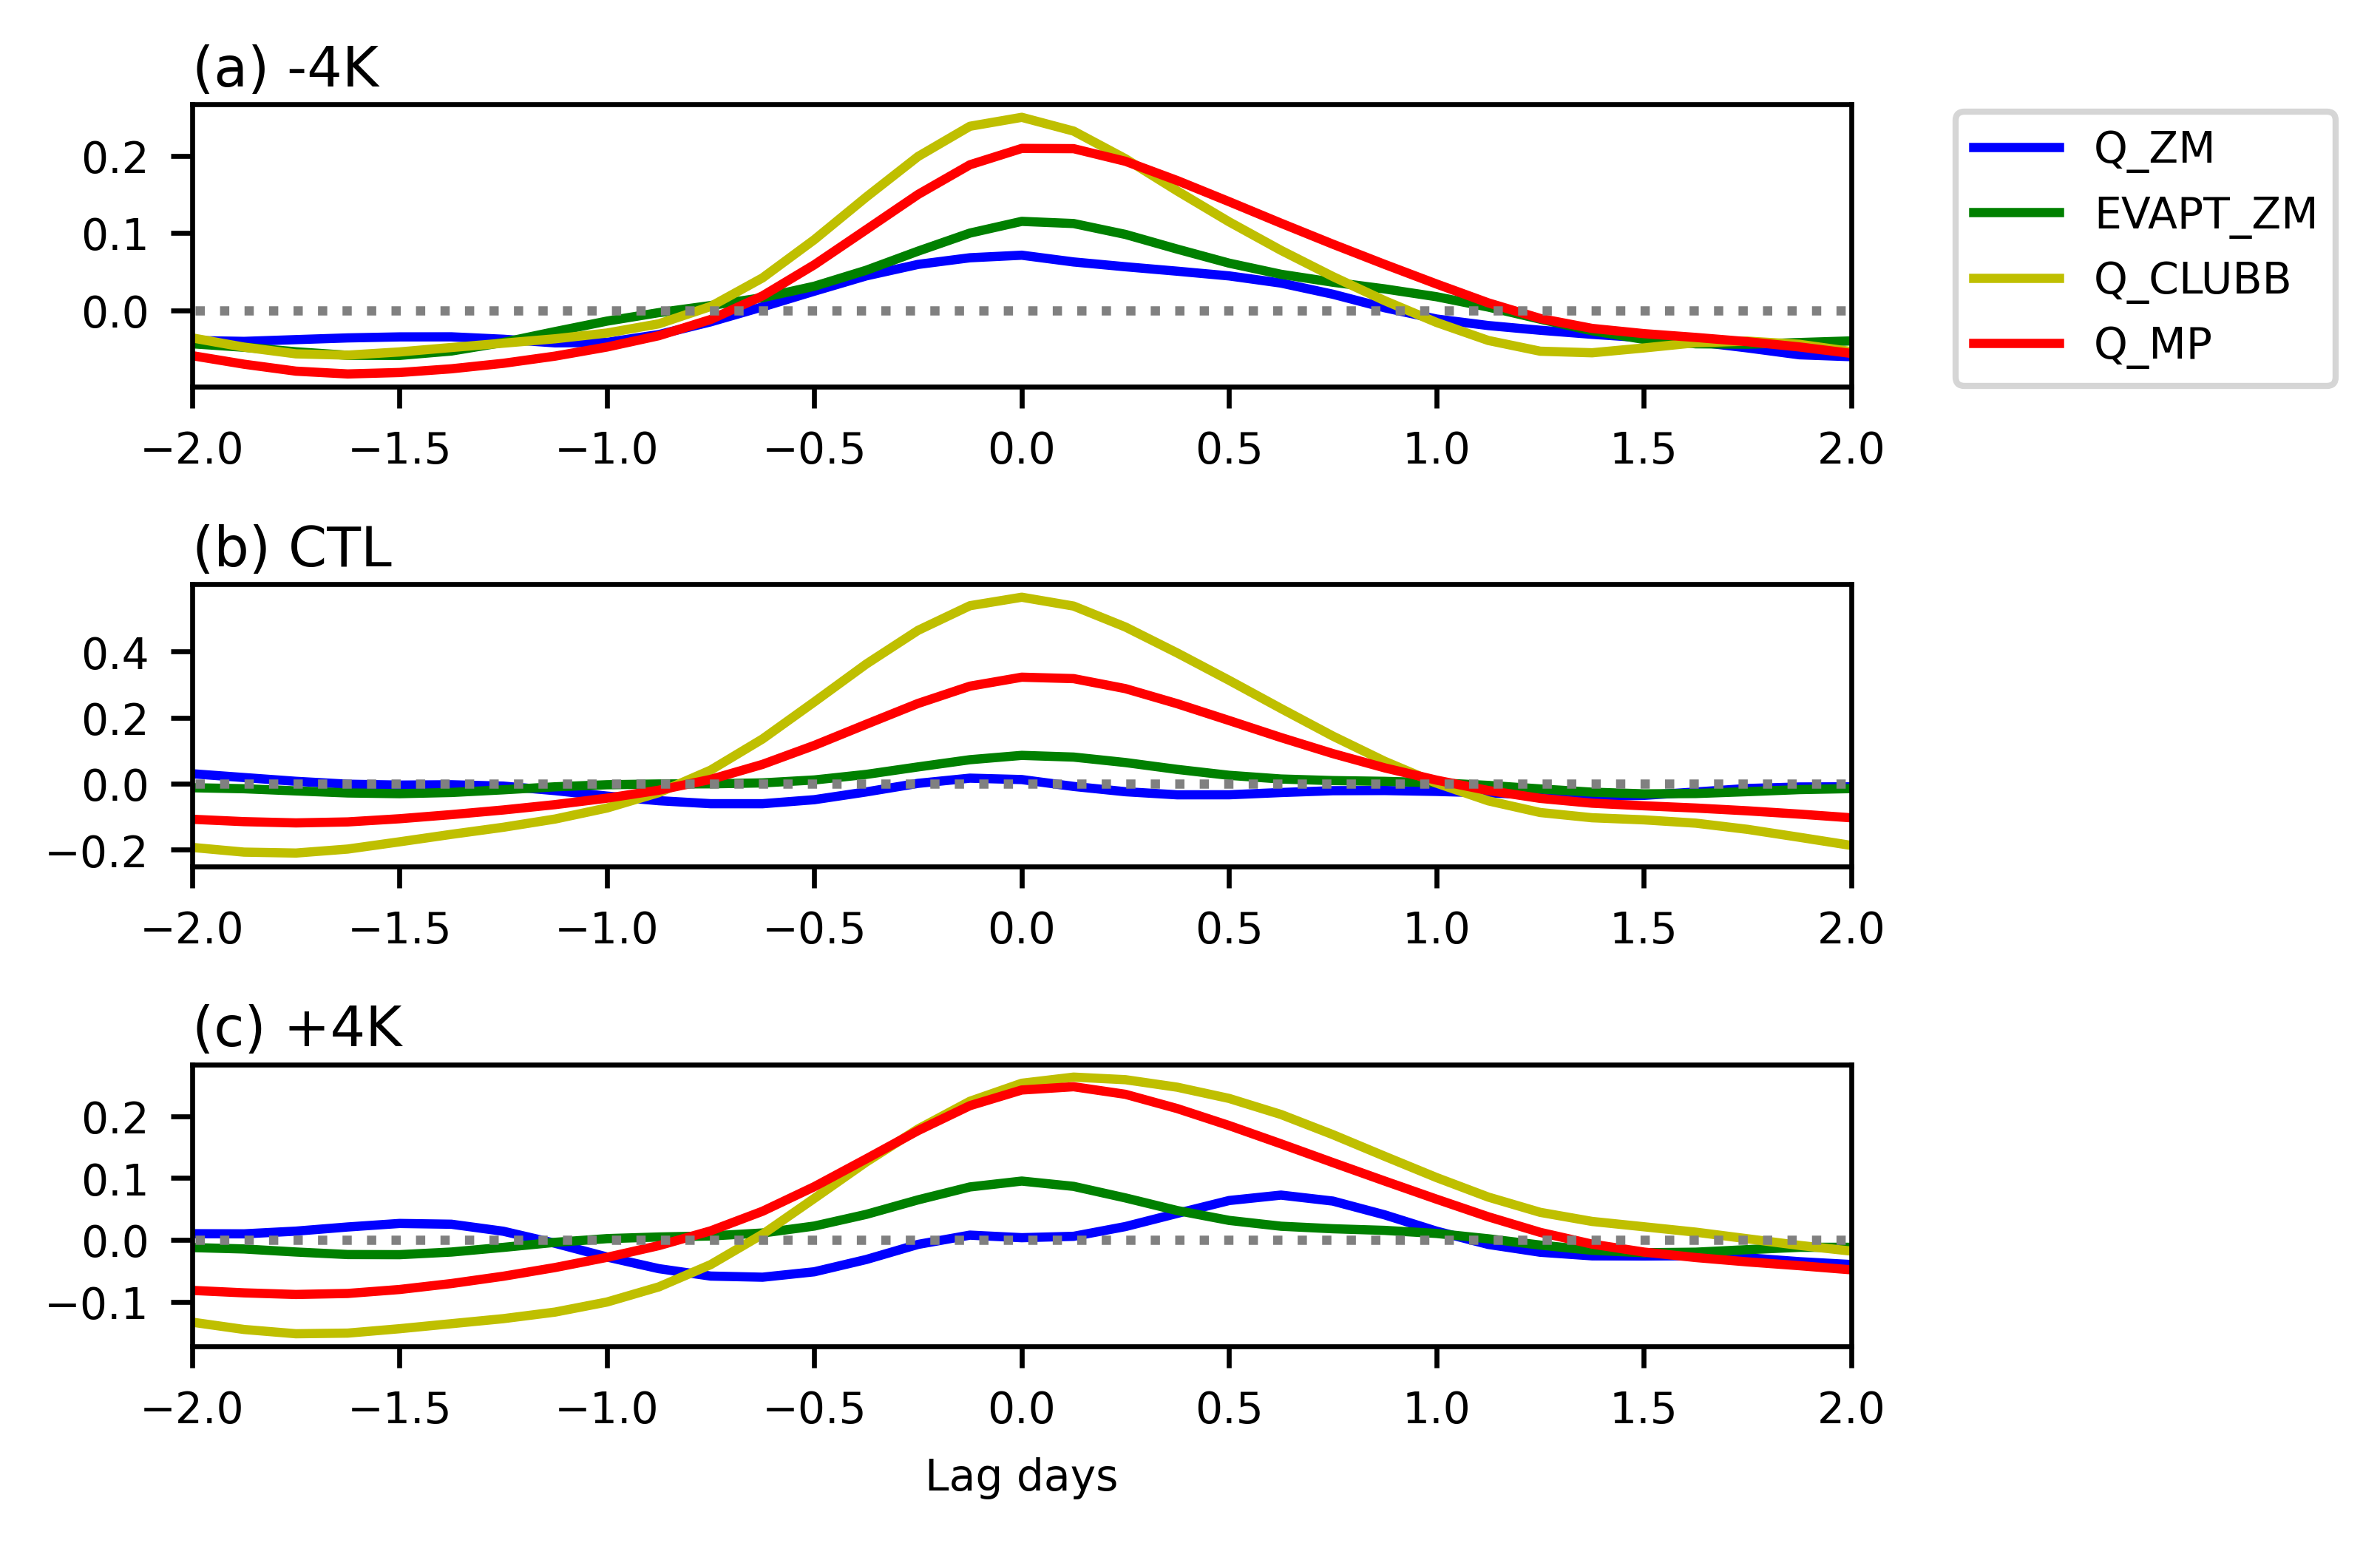

In [27]:
# PLot timeseries of each term
vname_list = list(['Q_ZM','EVAPT_ZM','Q_CLUBB','Q_MP'])
color_list = list(['b','g','y','r'])
title_list = list(['(a) -4K','(b) CTL','(c) +4K'])
font = 8
zero = np.zeros([np.size(lags)])
fig,axes = plt.subplots(3,1,figsize=(5.5, 4),dpi=600)
plt.subplots_adjust(left=0.1,right=0.78,top=0.9,bottom=0.2,wspace=0.2, hspace = 0.7)
plt.rcParams.update({'font.size': font})
for icase in range(0,3):
    plt.subplot(3,1,icase+1)
    for iplt in range(0, np.size(vname_list)):
        V = globals()[vname_list[iplt]+'_lag_plev_EOF2']
        #print(np.shape(V))
        #print(np.shape(lags))
        plt.plot(lags/8, V[:,icase], color=color_list[iplt])
        
        plt.xlim([-2,2])
        if iplt == 0:
            plt.title(title_list[icase], pad=3, loc='left',fontsize=9)
    if icase == 0:    
        plt.yticks(np.arange(-0.1,0.3,0.1))
        ax = plt.gca()
        ax.legend(vname_list, bbox_to_anchor=(1.05, 1.05), loc='upper left',fontsize=7)
    elif icase == 1:
        plt.yticks(np.arange(-0.2,0.6,0.2))
    elif icase == 2:
        plt.yticks(np.arange(-0.1,0.3,0.1))
        plt.xlabel('Lag days')
    plt.plot(lags/8, zero, color='grey',linestyle=':' )
        
plt.savefig(figdir+'Fig5_DTCOND_eof_proj_timeseries.png',dpi=600)  
plt.show()

In [ ]:
# If so, next step is to figure out how MP and EVAP-ZM depend on RH and qs-q

In [20]:
#################################
# Plot mean state RH and T
# Check if the lower peak of MP and EVAP match the mean state RH
#############################
data = np.load(output_dir_all_paper2+'mean_state_Tuvwq_all.npz') # other variables: um, vm, wm
lat  = data['lat']
plev = data['plev']
nlev = np.size(plev)

# Calculate average over 10S-10N
latmax = 10
latmin = -latmax
dmin = np.abs(lat-latmin)
dmax = np.abs(lat-latmax)
imin = np.argwhere(dmin==np.min(dmin)).squeeze()
imax = np.argwhere(dmax==np.min(dmax)).squeeze()
lat  = lat[imin:imax+1]
#
rhm  = data['rhm'][imin:imax+1,:,:] # (lat, plev, icase)
Tm   = data['Tm'][imin:imax+1,:,:]
qm   = data['qm'][imin:imax+1,:,:]
#
Tm_10SN  = MJO.mer_ave(Tm, lat, 0)-273.15 #C
rhm_10SN = MJO.mer_ave(rhm, lat, 0)
qm_10SN  = MJO.mer_ave(qm, lat, 0)*1000 #g/kg
qsm_10SN = qm_10SN/(rhm_10SN/100) # g/kg
dqm_10SN = qsm_10SN-qm_10SN # saturation deficit

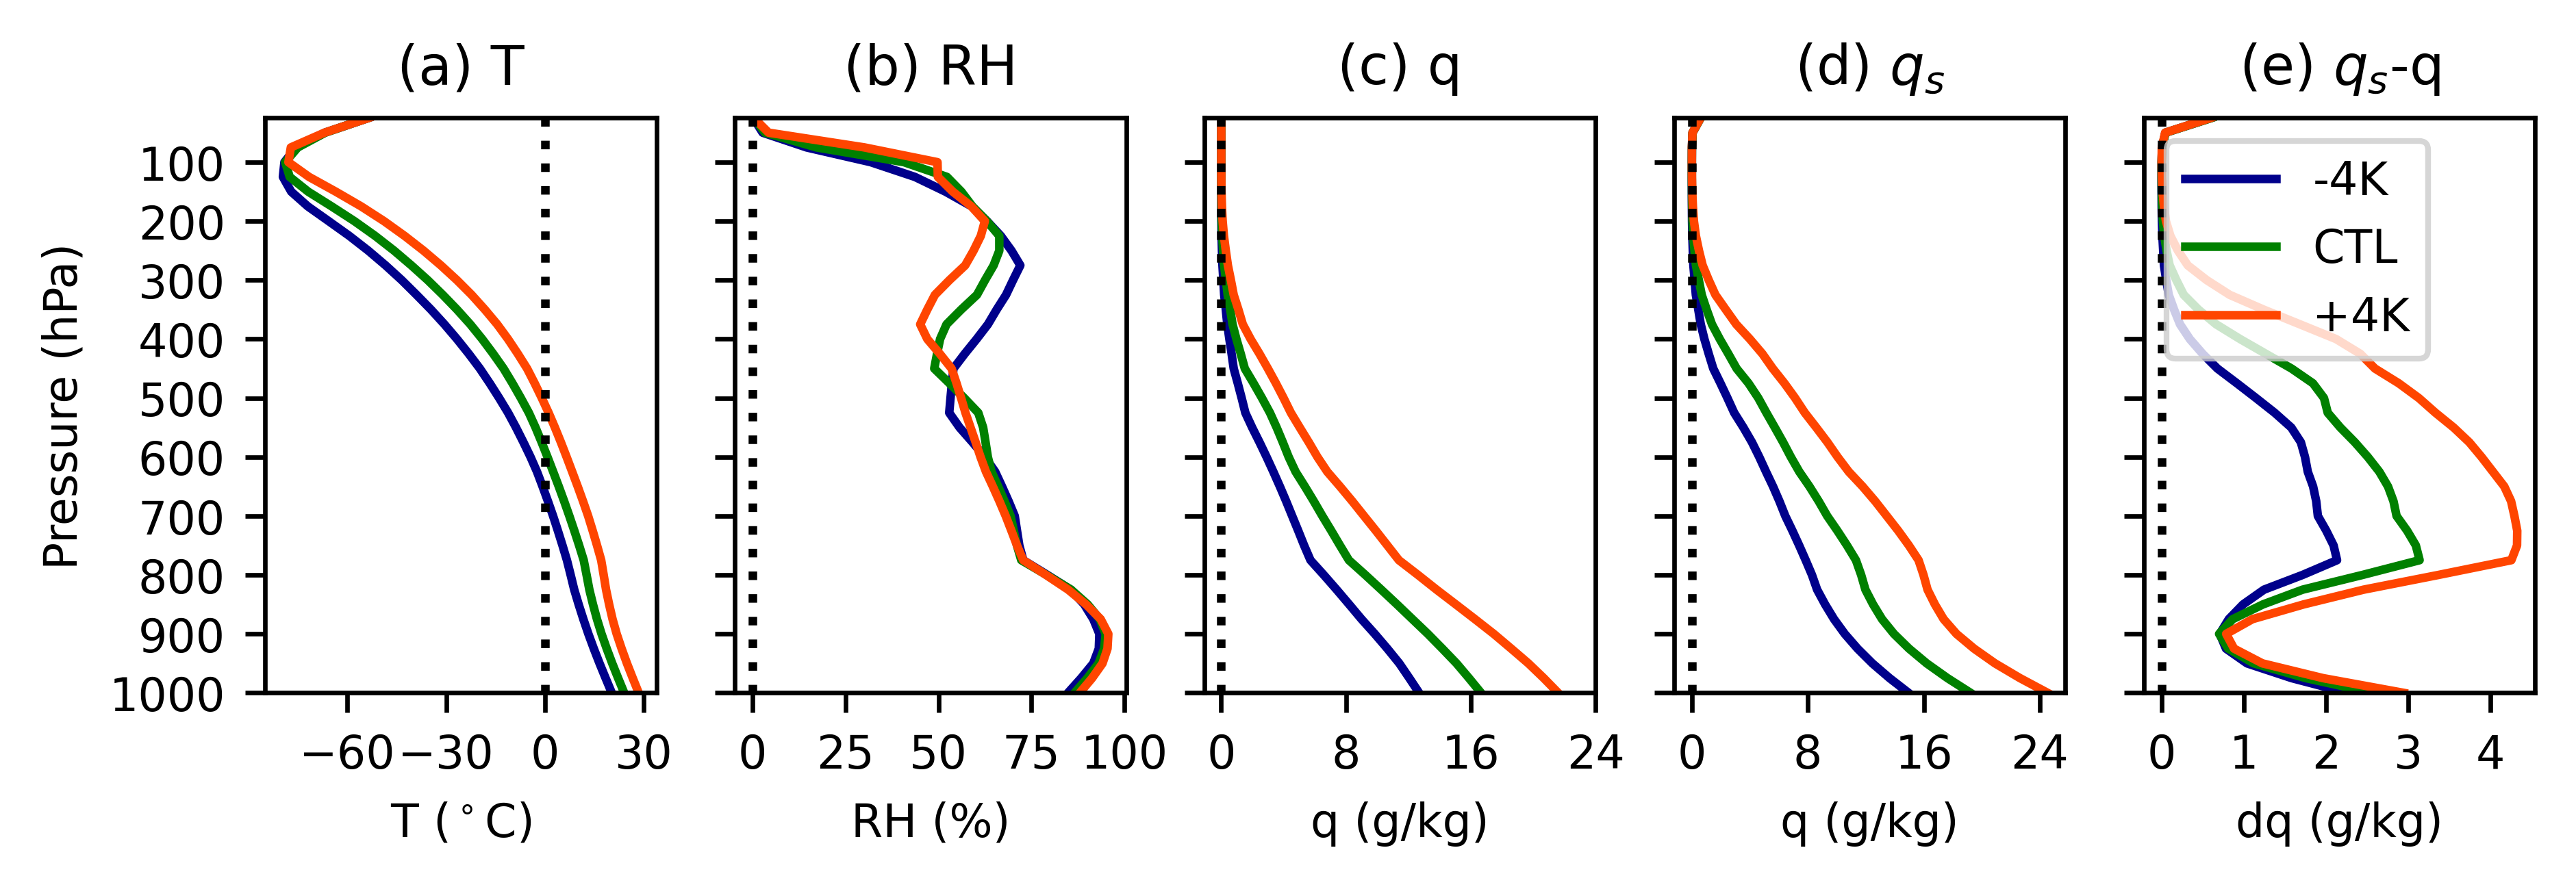

In [39]:
# Plot rhm, Tm, qm, dq
font = 8
for iplt in range(0, 1):
    if iplt == 0:
        V_list = list(['T','rh','q','qs','dq'])
        row_list = list(['(a) T','(b) RH','(c) q','(d) $q_{s}$','(e) $q_{s}$-q'])  
        xlabel_list = list(['T ($^\circ$C)','RH (%)','q (g/kg)','q (g/kg)','dq (g/kg)'])
    fig,axes = plt.subplots(1,5,figsize=(6.5, 2),dpi=600)
    plt.subplots_adjust(left=0.1,right=0.95,top=0.9,bottom=0.2,wspace=0.2)
    plt.rcParams.update({'font.size': font})
    zero = np.zeros([nlev])
    
    for icol in range(0,5):
        if iplt == 0:
            V = globals()[V_list[icol]+'m_10SN']
            
        plt.subplot(1,5,icol+1)
        plt.title( row_list[icol] )
        plt.plot( V[:,0], plev, color='darkblue')
        plt.plot( V[:,1], plev, color='green')
        plt.plot( V[:,2], plev, color='orangered')
        plt.plot( zero, plev, 'k:')
        plt.ylim( np.min(plev), np.max(plev) )
        if icol == 4:
            plt.legend(['-4K','CTL','+4K'], loc='upper left')
        if icol == 0:
            plt.xticks(np.arange(-60,60,30))
        elif icol == 1:
            plt.xticks(np.arange(0,125,25))
        elif icol == 2 or icol ==3:
            plt.xticks(np.arange(0,32,8))
        elif icol == 4:
            plt.xticks(np.arange(0,5,1))
            
        plt.yticks(np.arange(100,1100,100))
        if icol == 0:
            plt.tick_params(labelbottom=True,labeltop=False,labelleft=True,labelright=False)
            plt.ylabel('Pressure (hPa)')
        else:
            plt.tick_params(labelbottom=True,labeltop=False,labelleft=False,labelright=False)
        plt.gca().invert_yaxis()
        if iplt == 0:
            plt.xlabel(xlabel_list[icol])

    if iplt == 0:
        plt.savefig(figdir+'Fig4_mean_state_T-rh-q-qs-dq.png',dpi=600)  
    plt.show()

In [5]:
print(np.shape(Tm))

(96, 40, 3)
